# RetentionAI — Customer Churn Prediction

**Análise exploratória, descoberta de padrões, validação metodológica, modelagem preditiva e explicabilidade para identificação de risco de churn.**

Dataset: [Sales and Marketing Dataset (Kaggle)](https://www.kaggle.com/datasets/bhaskerpaul/sales-and-marketing-dataset)

---

## Sumário

1. Configuração do Ambiente
2. Carregamento dos Dados
3. Auditoria dos Dados
4. Limpeza dos Dados
5. Análise Exploratória (EDA)
6. Feature Engineering
7. Validação Metodológica e Machine Learning
8. Explainable AI (SHAP)
9. Insights de Negócio
10. Recomendações
11. Auditoria Final da Metodologia

> **Regra de integridade:** nenhum resultado, métrica, modelo vencedor, threshold ou insight é presumido. Os valores apresentados surgem apenas depois da execução dos cálculos correspondentes.

> **Regra de validação:** o conjunto final de teste é separado no início da modelagem e não participa da escolha de modelo, estratégia de desbalanceamento, hiperparâmetros, calibração ou threshold.

## 1. Configuração do Ambiente


In [3]:
print("TESTE")

TESTE


In [4]:
import sys
print("Python:", sys.executable)

import importlib.util
print("SHAP encontrado:", importlib.util.find_spec("shap"))

Python: c:\Users\RHADY\Documents\LIA 1\PRIMEIRA ATIVIDADE PART2\.venv\Scripts\python.exe
SHAP encontrado: ModuleSpec(name='shap', loader=<_frozen_importlib_external.SourceFileLoader object at 0x000001967E1E1490>, origin='c:\\Users\\RHADY\\Documents\\LIA 1\\PRIMEIRA ATIVIDADE PART2\\.venv\\Lib\\site-packages\\shap\\__init__.py', submodule_search_locations=['c:\\Users\\RHADY\\Documents\\LIA 1\\PRIMEIRA ATIVIDADE PART2\\.venv\\Lib\\site-packages\\shap'])


In [5]:
import shap
print("SHAP OK:", shap.__version__)

SHAP OK: 0.52.0


In [6]:
# Manipulação de dados
import json
import joblib
import pandas as pd
import numpy as np

# Estatística
from scipy import stats

# Machine Learning / avaliação final
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, precision_recall_curve

# Explicabilidade
import shap

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

# Utilitários do projeto
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data.paths import (
    RAW_DATA_DIR, PROCESSED_DATA_DIR, FIGURES_DIR, RESULTS_DIR, MODELS_DIR, ensure_dirs
)
from src.analysis.discovery import (
    build_association_rankings,
    top_categorical_segments,
    numeric_quantile_churn_summary,
    combination_churn_summary,
    candidate_categorical_pairs,
    build_dynamic_discoveries,
)
from src.analysis.leakage import build_leakage_audit
from src.validation import (
    build_candidate_pipeline,
    build_validation_audit,
    calibration_curve_table,
    class_distribution_table,
    compare_calibration_methods,
    compare_candidates,
    confusion_matrix_table,
    evaluate_candidate_cv,
    evaluate_dummy_baseline,
    final_test_evaluation,
    fit_final_estimator,
    make_cv,
    one_standard_error_selection,
    risk_decile_table,
    select_thresholds,
    split_integrity_checks,
    summarize_tuning,
    threshold_metrics_table,
    top_k_metrics,
    tune_candidate,
    choose_calibration_method,
)
from src.visualization.plots import (
    plot_churn_distribution,
    plot_roc_curves,
    plot_precision_recall_curves,
    plot_numeric_association_ranking,
    plot_categorical_association_ranking,
    plot_churn_rate_deviation,
    plot_quantile_churn,
    plot_combination_heatmap,
    plot_risk_value_scatter,
    plot_error_profile,
    plot_split_distribution,
    plot_cv_pr_auc,
    plot_imbalance_strategy_comparison,
    plot_stability,
    plot_train_cv_gap,
    plot_calibration_curves,
    plot_threshold_tradeoff,
    plot_lift_top_k,
    plot_risk_deciles,
)

ensure_dirs()


def save_fig(fig, filename, scale=2):
    """Salva Plotly em PNG quando o ambiente possui suporte a Kaleido/Chrome."""
    try:
        fig.write_image(str(FIGURES_DIR / filename), scale=scale)
    except Exception as exc:
        print(
            f"[aviso] Não foi possível salvar '{filename}' como PNG ({exc}). "
            "A visualização interativa permanece disponível."
        )


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")
pio.renderers.default = "notebook_connected"

print("Ambiente configurado com sucesso.")
print(f"Raiz do projeto: {PROJECT_ROOT}")

Ambiente configurado com sucesso.
Raiz do projeto: c:\Users\RHADY\Documents\LIA 1\PRIMEIRA ATIVIDADE PART2\retention-ai


## 2. Carregamento dos Dados

O dataset deve ter sido baixado do Kaggle e colocado em `data/raw/`
(instruções em [`data/README.md`](../data/README.md)).


In [7]:
RAW_FILENAME = "Sales_-_Marketing_customer_dataset.csv"
raw_path = RAW_DATA_DIR / RAW_FILENAME

if not raw_path.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado em: {raw_path}\n"
        "Baixe o dataset do Kaggle e coloque-o em 'data/raw/'. "
        "Veja data/README.md para instruções detalhadas."
    )

df = pd.read_csv(raw_path)
print(f"Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()


Dataset carregado: 15000 linhas x 30 colunas


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,coupon_code,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,1,7,13.903745,5.415164,0.67,0.26,559.524958,65.246704,0,NEW20,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,0,19,5.112528,5.352441,0.70,0.37,356.491344,48.473887,1,NEW20,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,1,18,9.742749,3.594719,0.47,0.44,689.332196,77.815371,0,NaN,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,1,16,9.642654,2.949531,0.58,0.37,445.429636,71.712192,0,NaN,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,0,12,7.791291,2.405539,0.05,0.16,686.286022,44.990246,1,NaN,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


## 3. Auditoria dos Dados

Antes de qualquer transformação, o notebook calcula dinamicamente dimensões, tipos, valores ausentes, duplicidades, cardinalidade, consistência e distribuição do target.

Nenhuma quantidade ou percentual é assumido previamente.

In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  str    
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  str    
 4   city                        15000 non-null  str    
 5   signup_date                 15000 non-null  str    
 6   last_purchase_date          15000 non-null  str    
 7   acquisition_channel         15000 non-null  str    
 8   device_type                 15000 non-null  str    
 9   subscription_type           15000 non-null  str    
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           15000 non-null

In [9]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
customer_id,15000.0,17500.500000,4330.271354,10001.000000,13750.750000,17500.500000,21250.250000,25000.000000
age,13800.0,35.203913,10.334384,-4.000000,28.000000,35.000000,42.000000,95.000000
is_premium_user,15000.0,0.304467,0.460197,0.000000,0.000000,0.000000,1.000000,1.000000
total_visits,15000.0,15.000933,3.892704,3.000000,12.000000,15.000000,18.000000,31.000000
avg_session_time,15000.0,8.020805,2.991499,0.006095,5.974555,7.991907,10.059986,19.123716
pages_per_session,15000.0,4.002901,1.479846,0.007845,2.989150,3.996992,5.014406,10.843172
email_open_rate,15000.0,0.496278,0.290108,0.000000,0.240000,0.500000,0.750000,1.000000
email_click_rate,15000.0,0.251231,0.144689,0.000000,0.130000,0.250000,0.380000,0.500000
total_spent,13950.0,524.357397,467.050070,0.267291,300.432074,498.843859,702.396635,15910.431879
avg_order_value,15000.0,60.080882,24.746203,0.071596,43.032470,60.108827,76.888445,154.554696


In [10]:
# Valores ausentes por coluna
missing = pd.DataFrame({
    "n_ausentes": df.isnull().sum(),
    "percentual_ausente": (df.isnull().mean() * 100).round(2)
}).sort_values("percentual_ausente", ascending=False)

missing[missing["n_ausentes"] > 0]


,n_ausentes,percentual_ausente
coupon_code,6133,40.89
age,1200,8.00
total_spent,1050,7.00
gender,738,4.92
satisfaction_score,702,4.68


In [11]:
# Duplicatas
print(f"Linhas duplicadas: {df.duplicated().sum()}")

# Cardinalidade das variáveis categóricas
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print("\nCardinalidade categórica:")
print(df[categorical_cols].nunique().sort_values(ascending=False))


Linhas duplicadas: 0

Cardinalidade categórica:
signup_date            1000
last_purchase_date      800
city                      7
country                   5
payment_method            5
acquisition_channel       5
gender                    3
device_type               3
coupon_code               3
subscription_type         2
dtype: int64


C:\Users\RHADY\AppData\Local\Temp\ipykernel_25240\853014108.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


In [12]:
# Verificação de consistência de valores: variáveis numéricas com limites plausíveis
# 'age' é o principal candidato a valores inválidos (idades negativas ou extremas)
print("Estatísticas de 'age':")
print(df["age"].describe())
print(f"\nRegistros com idade inválida (< 0 ou > 100): {((df['age'] < 0) | (df['age'] > 100)).sum()}")


Estatísticas de 'age':
count    13800.000000
mean        35.203913
std         10.334384
min         -4.000000
25%         28.000000
50%         35.000000
75%         42.000000
max         95.000000
Name: age, dtype: float64

Registros com idade inválida (< 0 ou > 100): 3


In [13]:
# Balanceamento da variável-alvo
churn_counts = df["churn"].value_counts()
churn_pct = df["churn"].value_counts(normalize=True) * 100
print("Distribuição de churn (contagem):")
print(churn_counts)
print("\nDistribuição de churn (%):")
print(churn_pct.round(2))


Distribuição de churn (contagem):
churn
0    12702
1     2298
Name: count, dtype: int64

Distribuição de churn (%):
churn
0    84.68
1    15.32
Name: proportion, dtype: float64


### Interpretação da auditoria

Use exclusivamente os outputs calculados acima para registrar os achados. Não presuma ausência de duplicatas, percentual de missing, proporção de churn ou significado de valores ausentes sem evidência.

Pontos que exigem decisão metodológica explícita:

- valores fisicamente/impossíveis podem ser convertidos para `NaN`, preservando a ausência;
- imputações aprendidas (mediana, moda etc.) **não são feitas aqui para a modelagem**: ficam dentro do pipeline e são aprendidas somente nos folds de treinamento;
- identificadores e possíveis variáveis temporais são auditados antes de entrar no modelo;
- ausência em `coupon_code` não é interpretada automaticamente como “não usou cupom” sem documentação.

# 🏢 Perguntas Empresariais sobre Churn

Nesta seção investigamos perguntas que poderiam ser realizadas por gestores, equipes de Customer Success, Marketing, CRM e áreas responsáveis pela retenção de clientes.

Todas as respostas apresentadas são calculadas exclusivamente a partir dos dados disponíveis no dataset.

Nenhum resultado é previamente assumido.

## 1. Qual é o tamanho do problema de churn?

Queremos compreender quantos clientes apresentaram churn e qual é a proporção em relação à base analisada.

In [45]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display, Markdown
from pandas.api.types import is_bool_dtype, is_numeric_dtype


TARGET = "churn"


def normalizar_churn(serie):
    """
    Converte a variável churn para 0/1 somente quando
    os valores existentes permitem fazer isso com segurança.
    """

    if is_bool_dtype(serie):
        return serie.astype(int)

    if is_numeric_dtype(serie):
        valores = set(serie.dropna().unique())

        if valores.issubset({0, 1}):
            return serie.astype(int)

    valores_texto = (
        serie.astype(str)
        .str.strip()
        .str.lower()
    )

    mapa = {
        "yes": 1,
        "no": 0,
        "true": 1,
        "false": 0,
        "churn": 1,
        "churned": 1,
        "stay": 0,
        "stayed": 0,
        "active": 0,
        "1": 1,
        "0": 0
    }

    convertida = valores_texto.map(mapa)

    if convertida.isna().any():
        valores_problematicos = (
            serie[convertida.isna()]
            .dropna()
            .unique()
        )

        raise ValueError(
            f"Não foi possível interpretar todos os valores de churn. "
            f"Valores encontrados: {valores_problematicos}"
        )

    return convertida.astype(int)


if TARGET not in df.columns:
    raise KeyError(
        f"A coluna '{TARGET}' não foi encontrada. "
        f"Colunas disponíveis: {df.columns.tolist()}"
    )

df = df.copy()

df["_churn_bin"] = normalizar_churn(df[TARGET])

df["_churn_label"] = df["_churn_bin"].map({
    0: "Permaneceu",
    1: "Churn"
})

print("Valores encontrados na variável churn:")
display(df[TARGET].value_counts(dropna=False))

print("\nVariável preparada para análise:")
display(df["_churn_label"].value_counts()) 

Valores encontrados na variável churn:


churn
0    12702
1     2298
Name: count, dtype: int64


Variável preparada para análise:


_churn_label
Permaneceu    12702
Churn          2298
Name: count, dtype: int64

funções que vamos reutilizar

In [46]:
def encontrar_coluna(df, candidatos):
    """
    Retorna o primeiro nome de coluna existente entre os candidatos.
    Não inventa colunas.
    """
    for coluna in candidatos:
        if coluna in df.columns:
            return coluna

    return None


def resumo_churn_categoria(df, coluna):
    """
    Resume churn por categoria.
    """

    tabela = (
        df.groupby(coluna, dropna=False)
        .agg(
            Clientes=("_churn_bin", "size"),
            Churners=("_churn_bin", "sum")
        )
        .reset_index()
    )

    tabela["Permaneceram"] = (
        tabela["Clientes"] - tabela["Churners"]
    )

    tabela["Taxa de churn (%)"] = (
        tabela["Churners"]
        / tabela["Clientes"]
        * 100
    )

    return tabela.sort_values(
        "Taxa de churn (%)",
        ascending=False
    ).reset_index(drop=True)


def resumo_numerico_churn(df, coluna):
    """
    Estatísticas da variável numérica separadas por churn.
    """

    tabela = (
        df.groupby("_churn_label")[coluna]
        .agg(
            Clientes="count",
            Média="mean",
            Mediana="median",
            Desvio_Padrão="std",
            Mínimo="min",
            Máximo="max"
        )
        .reset_index()
        .rename(columns={"_churn_label": "Situação"})
    )

    q1 = (
        df.groupby("_churn_label")[coluna]
        .quantile(0.25)
    )

    q3 = (
        df.groupby("_churn_label")[coluna]
        .quantile(0.75)
    )

    tabela["Q1"] = tabela["Situação"].map(q1)
    tabela["Q3"] = tabela["Situação"].map(q3)

    return tabela

Função para gráfico categórico + tabela + pergunta


In [47]:
def analisar_categoria(
    df,
    coluna,
    titulo,
    pergunta,
    impacto
):
    tabela = resumo_churn_categoria(df, coluna)

    fig = px.bar(
        tabela,
        x=coluna,
        y="Taxa de churn (%)",
        text="Taxa de churn (%)",
        custom_data=[
            "Clientes",
            "Churners",
            "Permaneceram"
        ],
        title=titulo
    )

    fig.update_traces(
        texttemplate="%{text:.1f}%",
        textposition="outside",
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Taxa de churn: %{y:.2f}%<br>"
            "Clientes: %{customdata[0]}<br>"
            "Churners: %{customdata[1]}<br>"
            "Permaneceram: %{customdata[2]}"
            "<extra></extra>"
        )
    )

    fig.update_layout(
        xaxis_title=coluna.replace("_", " ").title(),
        yaxis_title="Taxa de churn (%)",
        hovermode="closest"
    )

    fig.show()

    display(
        tabela.style.format({
            "Taxa de churn (%)": "{:.2f}%"
        })
    )

    maior = tabela.iloc[0]

    menor = tabela.iloc[-1]

    resposta = (
        f"A maior taxa observada ocorreu em "
        f"**{maior[coluna]}**, com "
        f"**{maior['Taxa de churn (%)']:.2f}%**, "
        f"considerando {int(maior['Clientes'])} clientes. "
        f"A menor taxa observada foi de "
        f"**{menor['Taxa de churn (%)']:.2f}%** em "
        f"**{menor[coluna]}**."
    )

    display(Markdown(f"""
### ❓ Pergunta empresarial

**{pergunta}**

### 📌 O que os dados mostram?

{resposta}

### 💡 Insight

Existem diferenças observadas na taxa de churn entre os grupos dessa variável.  
Essas diferenças devem ser investigadas juntamente com outras características antes de qualquer decisão.

### 🏢 Por que isso importa para a empresa?

{impacto}

### ⚠️ Limitação

Esta análise é **descritiva e associativa**. Ela não demonstra que a categoria analisada causa churn.  
Também é necessário observar o tamanho de cada grupo antes de considerar uma diferença empresarialmente relevante.
"""))

    return tabela

Função para variáveis numéricas

In [48]:
def analisar_numerica(
    df,
    coluna,
    titulo,
    pergunta,
    impacto
):
    dados = df[
        [coluna, "_churn_label"]
    ].dropna()

    fig = px.box(
        dados,
        x="_churn_label",
        y=coluna,
        points="outliers",
        title=titulo,
        labels={
            "_churn_label": "Situação do cliente",
            coluna: coluna.replace("_", " ").title()
        }
    )

    fig.update_layout(
        xaxis_title="Situação do cliente",
        yaxis_title=coluna.replace("_", " ").title()
    )

    fig.show()

    tabela = resumo_numerico_churn(
        df,
        coluna
    )

    display(
        tabela.style.format({
            "Média": "{:.2f}",
            "Mediana": "{:.2f}",
            "Desvio_Padrão": "{:.2f}",
            "Mínimo": "{:.2f}",
            "Máximo": "{:.2f}",
            "Q1": "{:.2f}",
            "Q3": "{:.2f}"
        })
    )

    mediana_churn = dados.loc[
        dados["_churn_label"] == "Churn",
        coluna
    ].median()

    mediana_permaneceu = dados.loc[
        dados["_churn_label"] == "Permaneceu",
        coluna
    ].median()

    diferenca = mediana_churn - mediana_permaneceu

    if diferenca > 0:
        direcao = "maior"
    elif diferenca < 0:
        direcao = "menor"
    else:
        direcao = "igual"

    resposta = (
        f"A mediana entre clientes com churn foi "
        f"**{mediana_churn:.2f}**, enquanto entre clientes "
        f"que permaneceram foi **{mediana_permaneceu:.2f}**. "
        f"Na amostra analisada, a mediana do grupo churn foi "
        f"**{direcao}**."
    )

    display(Markdown(f"""
### ❓ Pergunta empresarial

**{pergunta}**

### 📌 O que os dados mostram?

{resposta}

### 💡 Insight

A distribuição permite verificar se existem diferenças de comportamento entre os dois grupos, além de revelar dispersão e possíveis valores extremos.

### 🏢 Por que isso importa para a empresa?

{impacto}

### ⚠️ Limitação

Uma diferença observada entre os grupos não comprova causalidade.  
A relevância dessa diferença deverá posteriormente ser complementada pela análise estatística e pelo Machine Learning.
"""))

    return tabela

##Qual é o tamanho do churn?


In [49]:
total_clientes = len(df)

churners = int(df["_churn_bin"].sum())

permaneceram = total_clientes - churners

taxa_churn = (
    churners / total_clientes * 100
)

tabela_churn = pd.DataFrame({
    "Situação": [
        "Permaneceu",
        "Churn"
    ],
    "Clientes": [
        permaneceram,
        churners
    ]
})

tabela_churn["Percentual (%)"] = (
    tabela_churn["Clientes"]
    / total_clientes
    * 100
)

fig = px.bar(
    tabela_churn,
    x="Situação",
    y="Clientes",
    text="Clientes",
    custom_data=["Percentual (%)"],
    title="Quantos clientes permaneceram e quantos apresentaram churn?"
)

fig.update_traces(
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Clientes: %{y}<br>"
        "Percentual: %{customdata[0]:.2f}%"
        "<extra></extra>"
    )
)

fig.update_layout(
    xaxis_title="Situação do cliente",
    yaxis_title="Número de clientes"
)

fig.show()

display(
    tabela_churn.style.format({
        "Percentual (%)": "{:.2f}%"
    })
)

display(Markdown(f"""
### ❓ Pergunta empresarial

**Qual é o tamanho do problema de churn na base analisada?**

### 📌 O que os dados mostram?

Foram analisados **{total_clientes:,} clientes**.

- **{churners:,}** apresentaram churn.
- **{permaneceram:,}** permaneceram.
- A taxa observada de churn foi de **{taxa_churn:.2f}%**.

### 💡 Insight

Essa análise estabelece a dimensão inicial do problema de retenção e também permite avaliar o nível de desbalanceamento da variável-alvo.

### 🏢 Por que isso importa para a empresa?

Antes de desenvolver estratégias de retenção, a empresa precisa saber qual proporção de sua base está sendo perdida.

### ⚠️ Limitação

A taxa geral mostra a dimensão do churn, mas não explica quais características estão associadas a ele.
"""))

,Situação,Clientes,Percentual (%)
0,Permaneceu,12702,84.68%
1,Churn,2298,15.32%



### ❓ Pergunta empresarial

**Qual é o tamanho do problema de churn na base analisada?**

### 📌 O que os dados mostram?

Foram analisados **15,000 clientes**.

- **2,298** apresentaram churn.
- **12,702** permaneceram.
- A taxa observada de churn foi de **15.32%**.

### 💡 Insight

Essa análise estabelece a dimensão inicial do problema de retenção e também permite avaliar o nível de desbalanceamento da variável-alvo.

### 🏢 Por que isso importa para a empresa?

Antes de desenvolver estratégias de retenção, a empresa precisa saber qual proporção de sua base está sendo perdida.

### ⚠️ Limitação

A taxa geral mostra a dimensão do churn, mas não explica quais características estão associadas a ele.


##Tipo de assinatura

In [50]:
col_assinatura = encontrar_coluna(
    df,
    [
        "subscription_type",
        "subscription",
        "plan_type",
        "plan"
    ]
)

if col_assinatura is not None:

    tabela_assinatura = analisar_categoria(
        df=df,
        coluna=col_assinatura,
        titulo="Taxa de churn por tipo de assinatura",
        pergunta=(
            "Existem tipos de assinatura com maior "
            "taxa observada de churn?"
        ),
        impacto=(
            "Diferenças entre planos podem indicar grupos que "
            "merecem investigação sobre proposta de valor, "
            "experiência, preço ou relacionamento."
        )
    )

else:
    print(
        "Não foi encontrada uma coluna adequada "
        "para tipo de assinatura."
    )

,subscription_type,Clientes,Churners,Permaneceram,Taxa de churn (%)
0,Monthly,7666,1191,6475,15.54%
1,Annual,7334,1107,6227,15.09%



### ❓ Pergunta empresarial

**Existem tipos de assinatura com maior taxa observada de churn?**

### 📌 O que os dados mostram?

A maior taxa observada ocorreu em **Monthly**, com **15.54%**, considerando 7666 clientes. A menor taxa observada foi de **15.09%** em **Annual**.

### 💡 Insight

Existem diferenças observadas na taxa de churn entre os grupos dessa variável.  
Essas diferenças devem ser investigadas juntamente com outras características antes de qualquer decisão.

### 🏢 Por que isso importa para a empresa?

Diferenças entre planos podem indicar grupos que merecem investigação sobre proposta de valor, experiência, preço ou relacionamento.

### ⚠️ Limitação

Esta análise é **descritiva e associativa**. Ela não demonstra que a categoria analisada causa churn.  
Também é necessário observar o tamanho de cada grupo antes de considerar uma diferença empresarialmente relevante.


##Satisfação

In [51]:
col_satisfacao = encontrar_coluna(
    df,
    [
        "satisfaction_score",
        "customer_satisfaction",
        "satisfaction"
    ]
)

if col_satisfacao is not None:

    tabela_satisfacao = analisar_numerica(
        df=df,
        coluna=col_satisfacao,
        titulo=(
            "Como a satisfação difere entre clientes "
            "que permaneceram e clientes com churn?"
        ),
        pergunta=(
            "Clientes com churn apresentam níveis "
            "de satisfação diferentes?"
        ),
        impacto=(
            "Se houver uma diferença consistente, satisfação "
            "pode ser considerada um indicador importante "
            "para monitoramento de retenção."
        )
    )

else:
    print(
        "Não foi encontrada uma variável de satisfação."
    )

,Situação,Clientes,Média,Mediana,Desvio_Padrão,Mínimo,Máximo,Q1,Q3
0,Churn,2225,2.82,3.00,1.30,1.00,5.00,2.00,4.00
1,Permaneceu,12073,3.73,4.00,0.98,1.00,5.00,3.00,4.00



### ❓ Pergunta empresarial

**Clientes com churn apresentam níveis de satisfação diferentes?**

### 📌 O que os dados mostram?

A mediana entre clientes com churn foi **3.00**, enquanto entre clientes que permaneceram foi **4.00**. Na amostra analisada, a mediana do grupo churn foi **menor**.

### 💡 Insight

A distribuição permite verificar se existem diferenças de comportamento entre os dois grupos, além de revelar dispersão e possíveis valores extremos.

### 🏢 Por que isso importa para a empresa?

Se houver uma diferença consistente, satisfação pode ser considerada um indicador importante para monitoramento de retenção.

### ⚠️ Limitação

Uma diferença observada entre os grupos não comprova causalidade.  
A relevância dessa diferença deverá posteriormente ser complementada pela análise estatística e pelo Machine Learning.


##Frequência recente de compras

In [52]:
col_frequencia = encontrar_coluna(
    df,
    [
        "last_3_month_purchase_freq",
        "purchase_frequency",
        "purchase_freq",
        "frequency"
    ]
)

if col_frequencia is not None:

    tabela_frequencia = analisar_numerica(
        df=df,
        coluna=col_frequencia,
        titulo=(
            "Frequência de compras: clientes com churn "
            "versus clientes que permaneceram"
        ),
        pergunta=(
            "Clientes que apresentam churn possuem "
            "frequência de compras diferente?"
        ),
        impacto=(
            "Uma redução de atividade pode ser útil para "
            "identificar clientes que precisam ser investigados "
            "antes do abandono."
        )
    )

else:
    print(
        "Não foi encontrada uma variável adequada "
        "de frequência de compras."
    )

,Situação,Clientes,Média,Mediana,Desvio_Padrão,Mínimo,Máximo,Q1,Q3
0,Churn,2298,6.99,7.00,4.30,0.00,14.00,3.00,11.00
1,Permaneceu,12702,6.97,7.00,4.33,0.00,14.00,3.00,11.00



### ❓ Pergunta empresarial

**Clientes que apresentam churn possuem frequência de compras diferente?**

### 📌 O que os dados mostram?

A mediana entre clientes com churn foi **7.00**, enquanto entre clientes que permaneceram foi **7.00**. Na amostra analisada, a mediana do grupo churn foi **igual**.

### 💡 Insight

A distribuição permite verificar se existem diferenças de comportamento entre os dois grupos, além de revelar dispersão e possíveis valores extremos.

### 🏢 Por que isso importa para a empresa?

Uma redução de atividade pode ser útil para identificar clientes que precisam ser investigados antes do abandono.

### ⚠️ Limitação

Uma diferença observada entre os grupos não comprova causalidade.  
A relevância dessa diferença deverá posteriormente ser complementada pela análise estatística e pelo Machine Learning.


##Tickets de suporte

In [53]:
col_suporte = encontrar_coluna(
    df,
    [
        "support_tickets",
        "support_ticket_count",
        "customer_service_calls",
        "support_calls"
    ]
)

if col_suporte is not None:

    tabela_suporte = analisar_numerica(
        df=df,
        coluna=col_suporte,
        titulo=(
            "Uso do suporte entre clientes com churn "
            "e clientes que permaneceram"
        ),
        pergunta=(
            "Clientes que utilizam mais o suporte "
            "apresentam comportamento de churn diferente?"
        ),
        impacto=(
            "Uma concentração de contatos de suporte entre "
            "clientes em churn poderia ajudar a empresa a "
            "investigar problemas recorrentes na experiência."
        )
    )

else:
    print(
        "Não foi encontrada uma variável de suporte."
    )

,Situação,Clientes,Média,Mediana,Desvio_Padrão,Mínimo,Máximo,Q1,Q3
0,Churn,2298,2.42,2.00,1.77,0.00,9.00,1.00,3.00
1,Permaneceu,12702,1.92,2.00,1.33,0.00,9.00,1.00,3.00



### ❓ Pergunta empresarial

**Clientes que utilizam mais o suporte apresentam comportamento de churn diferente?**

### 📌 O que os dados mostram?

A mediana entre clientes com churn foi **2.00**, enquanto entre clientes que permaneceram foi **2.00**. Na amostra analisada, a mediana do grupo churn foi **igual**.

### 💡 Insight

A distribuição permite verificar se existem diferenças de comportamento entre os dois grupos, além de revelar dispersão e possíveis valores extremos.

### 🏢 Por que isso importa para a empresa?

Uma concentração de contatos de suporte entre clientes em churn poderia ajudar a empresa a investigar problemas recorrentes na experiência.

### ⚠️ Limitação

Uma diferença observada entre os grupos não comprova causalidade.  
A relevância dessa diferença deverá posteriormente ser complementada pela análise estatística e pelo Machine Learning.


##Reembolso

In [54]:
col_reembolso = encontrar_coluna(
    df,
    [
        "refund_requested",
        "refund",
        "requested_refund",
        "return_requested"
    ]
)

if col_reembolso is not None:

    tabela_reembolso = analisar_categoria(
        df=df,
        coluna=col_reembolso,
        titulo="Taxa de churn segundo solicitação de reembolso",
        pergunta=(
            "Clientes que solicitaram reembolso apresentam "
            "taxa de churn diferente?"
        ),
        impacto=(
            "Pedidos de reembolso podem representar um ponto "
            "importante da jornada do cliente e indicar situações "
            "que merecem acompanhamento."
        )
    )

else:
    print(
        "Não foi encontrada uma variável de reembolso."
    )

,refund_requested,Clientes,Churners,Permaneceram,Taxa de churn (%)
0,0,12785,1972,10813,15.42%
1,1,2215,326,1889,14.72%



### ❓ Pergunta empresarial

**Clientes que solicitaram reembolso apresentam taxa de churn diferente?**

### 📌 O que os dados mostram?

A maior taxa observada ocorreu em **0.0**, com **15.42%**, considerando 12785 clientes. A menor taxa observada foi de **14.72%** em **1.0**.

### 💡 Insight

Existem diferenças observadas na taxa de churn entre os grupos dessa variável.  
Essas diferenças devem ser investigadas juntamente com outras características antes de qualquer decisão.

### 🏢 Por que isso importa para a empresa?

Pedidos de reembolso podem representar um ponto importante da jornada do cliente e indicar situações que merecem acompanhamento.

### ⚠️ Limitação

Esta análise é **descritiva e associativa**. Ela não demonstra que a categoria analisada causa churn.  
Também é necessário observar o tamanho de cada grupo antes de considerar uma diferença empresarialmente relevante.


##Canal de aquisição

In [55]:
col_canal = encontrar_coluna(
    df,
    [
        "acquisition_channel",
        "channel_of_acquisition",
        "marketing_channel",
        "channel"
    ]
)

if col_canal is not None:

    tabela_canal = analisar_categoria(
        df=df,
        coluna=col_canal,
        titulo="Taxa de churn por canal de aquisição",
        pergunta=(
            "Os clientes adquiridos por diferentes canais "
            "apresentam taxas de churn diferentes?"
        ),
        impacto=(
            "Essa análise pode ajudar Marketing a avaliar "
            "não apenas quantos clientes cada canal adquire, "
            "mas também a retenção observada desses clientes."
        )
    )

else:
    print(
        "Não foi encontrada uma coluna adequada "
        "de canal de aquisição."
    )

,acquisition_channel,Clientes,Churners,Permaneceram,Taxa de churn (%)
0,Organic,3055,485,2570,15.88%
1,Referral,2941,464,2477,15.78%
2,Google Ads,3047,462,2585,15.16%
3,Email,2933,439,2494,14.97%
4,Facebook Ads,3024,448,2576,14.81%



### ❓ Pergunta empresarial

**Os clientes adquiridos por diferentes canais apresentam taxas de churn diferentes?**

### 📌 O que os dados mostram?

A maior taxa observada ocorreu em **Organic**, com **15.88%**, considerando 3055 clientes. A menor taxa observada foi de **14.81%** em **Facebook Ads**.

### 💡 Insight

Existem diferenças observadas na taxa de churn entre os grupos dessa variável.  
Essas diferenças devem ser investigadas juntamente com outras características antes de qualquer decisão.

### 🏢 Por que isso importa para a empresa?

Essa análise pode ajudar Marketing a avaliar não apenas quantos clientes cada canal adquire, mas também a retenção observada desses clientes.

### ⚠️ Limitação

Esta análise é **descritiva e associativa**. Ela não demonstra que a categoria analisada causa churn.  
Também é necessário observar o tamanho de cada grupo antes de considerar uma diferença empresarialmente relevante.


##Gasto total

In [56]:
col_gasto = encontrar_coluna(
    df,
    [
        "total_spent",
        "total_spend",
        "customer_spend",
        "total_revenue"
    ]
)

if col_gasto is not None:

    tabela_gasto = analisar_numerica(
        df=df,
        coluna=col_gasto,
        titulo=(
            "Distribuição do gasto total entre clientes "
            "que permaneceram e clientes com churn"
        ),
        pergunta=(
            "Clientes que apresentam churn possuem "
            "comportamento de gasto diferente?"
        ),
        impacto=(
            "Compreender o valor associado aos clientes em churn "
            "ajuda a avaliar se a perda está concentrada apenas "
            "em clientes de baixo valor ou se também envolve "
            "clientes economicamente relevantes."
        )
    )

else:
    print(
        "Não foi encontrada uma variável de gasto total."
    )

,Situação,Clientes,Média,Mediana,Desvio_Padrão,Mínimo,Máximo,Q1,Q3
0,Churn,2193,347.79,221.23,294.55,0.61,1400.57,110.18,549.54
1,Permaneceu,11757,557.29,524.77,485.54,0.27,15910.43,346.80,719.31



### ❓ Pergunta empresarial

**Clientes que apresentam churn possuem comportamento de gasto diferente?**

### 📌 O que os dados mostram?

A mediana entre clientes com churn foi **221.23**, enquanto entre clientes que permaneceram foi **524.77**. Na amostra analisada, a mediana do grupo churn foi **menor**.

### 💡 Insight

A distribuição permite verificar se existem diferenças de comportamento entre os dois grupos, além de revelar dispersão e possíveis valores extremos.

### 🏢 Por que isso importa para a empresa?

Compreender o valor associado aos clientes em churn ajuda a avaliar se a perda está concentrada apenas em clientes de baixo valor ou se também envolve clientes economicamente relevantes.

### ⚠️ Limitação

Uma diferença observada entre os grupos não comprova causalidade.  
A relevância dessa diferença deverá posteriormente ser complementada pela análise estatística e pelo Machine Learning.


##Lifetime Value

In [57]:
col_ltv = encontrar_coluna(
    df,
    [
        "lifetime_value",
        "customer_lifetime_value",
        "clv",
        "ltv"
    ]
)

if col_ltv is not None:

    tabela_ltv = analisar_numerica(
        df=df,
        coluna=col_ltv,
        titulo=(
            "Lifetime Value dos clientes que permaneceram "
            "e dos clientes com churn"
        ),
        pergunta=(
            "Clientes que apresentam churn possuem "
            "Lifetime Value diferente?"
        ),
        impacto=(
            "Combinar risco de churn e valor do cliente pode "
            "ser útil futuramente para definir prioridades "
            "de retenção."
        )
    )

else:
    print(
        "Não foi encontrada uma variável de Lifetime Value."
    )

,Situação,Clientes,Média,Mediana,Desvio_Padrão,Mínimo,Máximo,Q1,Q3
0,Churn,2298,1245.36,1225.02,659.24,0.37,3767.49,747.83,1694.32
1,Permaneceu,12702,1233.95,1214.54,657.22,0.54,3720.75,738.98,1673.36



### ❓ Pergunta empresarial

**Clientes que apresentam churn possuem Lifetime Value diferente?**

### 📌 O que os dados mostram?

A mediana entre clientes com churn foi **1225.02**, enquanto entre clientes que permaneceram foi **1214.54**. Na amostra analisada, a mediana do grupo churn foi **maior**.

### 💡 Insight

A distribuição permite verificar se existem diferenças de comportamento entre os dois grupos, além de revelar dispersão e possíveis valores extremos.

### 🏢 Por que isso importa para a empresa?

Combinar risco de churn e valor do cliente pode ser útil futuramente para definir prioridades de retenção.

### ⚠️ Limitação

Uma diferença observada entre os grupos não comprova causalidade.  
A relevância dessa diferença deverá posteriormente ser complementada pela análise estatística e pelo Machine Learning.


## 4. Limpeza dos Dados

A limpeza é separada do pré-processamento aprendido pelo modelo.

Nesta etapa são permitidas apenas transformações determinísticas e verificáveis, como:

1. converter valores de idade fisicamente inválidos para `NaN`;
2. normalizar tipos de data com `errors="coerce"`;
3. criar rótulo textual de churn apenas para visualização;
4. preservar valores ausentes para que imputação estatística seja aprendida **dentro do pipeline de cross-validation**.

Assim, mediana/moda não são calculadas sobre treino + teste antes do split.

In [15]:
df_clean = df.copy()

# 1. Idades fora de uma faixa fisicamente plausível viram missing.
# Não imputar aqui: a imputação da modelagem acontecerá dentro do pipeline.
if "age" in df_clean.columns:
    invalid_age = (df_clean["age"] < 0) | (df_clean["age"] > 120)
    df_clean.loc[invalid_age, "age"] = np.nan

# 2. Datas: conversão determinística; valores inválidos permanecem NaT.
for date_col in ["signup_date", "last_purchase_date"]:
    if date_col in df_clean.columns:
        df_clean[date_col] = pd.to_datetime(df_clean[date_col], errors="coerce")

# 3. Não inferir que coupon_code ausente significa ausência de uso.
# A ausência permanece missing e pode ser tratada explicitamente dentro do pipeline.

print(f"Dataset após limpeza estrutural: {df_clean.shape[0]} linhas x {df_clean.shape[1]} colunas")
print("Valores ausentes preservados para tratamento anti-leakage no pipeline:")
display(
    pd.DataFrame({
        "n_ausentes": df_clean.isna().sum(),
        "percentual": df_clean.isna().mean().mul(100)
    }).query("n_ausentes > 0").sort_values("percentual", ascending=False)
)

Dataset após limpeza estrutural: 15000 linhas x 32 colunas
Valores ausentes preservados para tratamento anti-leakage no pipeline:


,n_ausentes,percentual
coupon_code,6133,40.886667
age,1203,8.020000
total_spent,1050,7.000000
gender,738,4.920000
satisfaction_score,702,4.680000


In [16]:
# Persistir versão estruturalmente limpa (sem imputações aprendidas sobre toda a base)
df_clean.to_csv(PROCESSED_DATA_DIR / "churn_clean.csv", index=False)
print(f"Dados limpos salvos em: {PROCESSED_DATA_DIR / 'churn_clean.csv'}")

Dados limpos salvos em: C:\Users\RHADY\Documents\LIA 1\PRIMEIRA ATIVIDADE PART2\retention-ai\data\processed\churn_clean.csv


## 5. Análise Exploratória (EDA)

In [17]:
CHURN_LABEL_MAP = {0: "Permaneceu", 1: "Churn"}
df_clean["churn_label"] = df_clean["churn"].map(CHURN_LABEL_MAP)

churn_rate = df_clean["churn"].mean() * 100
print(f"Taxa geral de churn: {churn_rate:.2f}%")


Taxa geral de churn: 15.32%


In [18]:
fig_churn_dist = plot_churn_distribution(df_clean, churn_col="churn_label")
fig_churn_dist.show()
save_fig(fig_churn_dist, "churn_distribution.png")


### 5.1 Churn por variáveis categóricas de negócio

Canal de aquisição, tipo de assinatura, dispositivo, método de pagamento e país.


In [19]:
def plot_categorical_churn(df, col, top_n=None):
    data = df.copy()
    if top_n:
        top_categories = data[col].value_counts().nlargest(top_n).index
        data = data[data[col].isin(top_categories)]

    grouped = (
        data.groupby([col, "churn_label"])
        .size()
        .reset_index(name="quantidade")
    )
    totals = grouped.groupby(col)["quantidade"].transform("sum")
    grouped["percentual"] = (grouped["quantidade"] / totals * 100).round(1)

    fig = px.bar(
        grouped,
        x=col,
        y="quantidade",
        color="churn_label",
        color_discrete_map={"Churn": "#EF553B", "Permaneceu": "#00CC96"},
        barmode="group",
        text=grouped.apply(lambda r: f"{r['quantidade']} ({r['percentual']}%)", axis=1),
        title=f"Churn por {col}",
        labels={col: col, "quantidade": "Número de Clientes", "churn_label": "Status"},
    )
    fig.update_traces(textposition="outside")
    return fig


for col in ["acquisition_channel", "subscription_type", "device_type", "payment_method", "country"]:
    fig = plot_categorical_churn(df_clean, col)
    fig.show()
    save_fig(fig, f"churn_by_{col}.png")


### 5.2 Churn por variáveis numéricas

As variáveis abaixo são perguntas exploratórias, não conclusões. Os gráficos usam os valores observados disponíveis; linhas com missing não são preenchidas artificialmente apenas para melhorar a aparência.

In [20]:
numeric_eda_candidates = [
    c for c in ["satisfaction_score", "total_spent", "support_tickets"]
    if c in df_clean.columns
]

for col in numeric_eda_candidates:
    fig = px.box(
        df_clean,
        x="churn_label",
        y=col,
        color="churn_label",
        color_discrete_map={"Churn": "#EF553B", "Permaneceu": "#00CC96"},
        title=f"Distribuição de {col} por Status de Churn",
        labels={"churn_label": "Status do Cliente", col: col},
        points=False,
    )
    fig.show()
    save_fig(fig, f"churn_by_{col}.png")

### 5.3 Correlação com a variável-alvo

Correlação de Pearson entre cada variável numérica e `churn`, para orientar a priorização
de features (correlação não implica causalidade).


In [21]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
corr_with_churn = (
    df_clean[numeric_cols].corr()["churn"]
    .drop(["churn", "customer_id"], errors="ignore")
    .sort_values()
)

fig_corr_churn = px.bar(
    corr_with_churn,
    orientation="h",
    title="Correlação de Pearson das Variáveis Numéricas com Churn",
    labels={"value": "Correlação com Churn", "index": "Variável"},
)
fig_corr_churn.show()
save_fig(fig_corr_churn, "correlation_with_churn.png")


In [22]:
# Matriz de correlação completa entre variáveis numéricas
corr = df_clean[numeric_cols].drop(columns=["customer_id"]).corr()

fig_corr = px.imshow(
    corr,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    title="Matriz de Correlação — Variáveis Numéricas",
    aspect="auto",
)
fig_corr.show()


### 5.4 🔎 Descobertas e Insights Relevantes dos Dados

Além das perguntas definidas previamente, esta etapa procura **padrões emergentes nos dados** sem assumir antecipadamente qual será o resultado.

A sequência adotada é:

**dados reais → cálculo → visualização → validação → interpretação → insight**

Regras desta seção:

- rankings numéricos e categóricos usam métricas separadas e compatíveis com cada tipo de variável;
- p-values de múltiplos testes são ajustados por **Benjamini-Hochberg (FDR)**;
- segmentos pequenos são sinalizados e não são destacados como evidência forte;
- gráficos por quantis são usados para revelar possíveis relações não lineares;
- combinações de segmentos só são exibidas quando há observações suficientes;
- nenhum insight é escrito antes de os cálculos serem executados;
- ausência de evidência também é um resultado válido.

In [23]:
# 5.4.1 Ranking de associações — métricas separadas por tipo de variável
# IDs e datas não são usados como variáveis explicativas nesta etapa.
DISCOVERY_EXCLUDE = [
    "customer_id", "signup_date", "last_purchase_date", "churn_label"
]

numeric_discovery, categorical_discovery = build_association_rankings(
    df_clean,
    target="churn",
    exclude_columns=DISCOVERY_EXCLUDE,
    max_categories=30,
)

print("Ranking numérico — magnitude do efeito rank-biserial:")
if not numeric_discovery.empty:
    display(
        numeric_discovery[
            [
                "variavel", "n", "media_churn", "media_permaneceu",
                "mediana_churn", "mediana_permaneceu",
                "rank_biserial", "p_value_fdr"
            ]
        ].head(15)
    )
    fig_num_discovery = plot_numeric_association_ranking(numeric_discovery, top_n=12)
    fig_num_discovery.show()
    save_fig(fig_num_discovery, "discovery_numeric_associations.png")
else:
    print("Dado ainda não disponível: não há variáveis numéricas válidas para este ranking.")

print("\nRanking categórico — Cramér's V:")
if not categorical_discovery.empty:
    display(
        categorical_discovery[
            ["variavel", "n", "n_categorias", "cramers_v", "p_value_fdr"]
        ].head(15)
    )
    fig_cat_discovery = plot_categorical_association_ranking(categorical_discovery, top_n=12)
    fig_cat_discovery.show()
    save_fig(fig_cat_discovery, "discovery_categorical_associations.png")
else:
    print("Dado ainda não disponível: não há variáveis categóricas válidas para este ranking.")

Ranking numérico — magnitude do efeito rank-biserial:


,variavel,n,media_churn,media_permaneceu,mediana_churn,mediana_permaneceu,rank_biserial,p_value_fdr
0,_churn_bin,15000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000e+00
1,total_spent,13950,347.791180,557.291795,221.225962,524.766253,-0.406603,1.193085e-200
2,satisfaction_score,14298,2.818876,3.730639,3.000000,4.000000,-0.400953,2.426925e-215
3,support_tickets,15000,2.422977,1.918281,2.000000,2.000000,0.135147,1.299860e-25
4,total_visits,15000,15.121845,14.979058,15.000000,15.000000,0.023911,2.006225e-01
5,age,13797,35.332226,35.190419,35.000000,35.000000,0.015971,6.056905e-01
6,email_open_rate,15000,0.490522,0.497319,0.490000,0.500000,-0.013572,6.422645e-01
7,marketing_spend_per_user,15000,17.451706,17.597587,17.405000,17.655000,-0.011627,6.568002e-01
8,nps_score,15000,5.011314,4.960951,5.000000,5.000000,0.009057,6.830231e-01
9,is_premium_user,15000,0.298520,0.305542,0.000000,0.000000,-0.007022,6.830231e-01



Ranking categórico — Cramér's V:


,variavel,n,n_categorias,cramers_v,p_value_fdr
0,_churn_label,15000,2,0.999743,0.000000
1,gender,14262,3,0.023905,0.076457
2,country,15000,5,0.020156,0.432583
3,coupon_code,8867,3,0.020003,0.432583
4,city,15000,7,0.016319,0.711079
5,payment_method,15000,5,0.013764,0.711079
6,acquisition_channel,15000,5,0.011928,0.711079
7,device_type,15000,3,0.010674,0.699269
8,subscription_type,15000,2,0.005950,0.699269


In [24]:
# 5.4.2 Segmentos com maior desvio em relação à taxa geral de churn
# Inclui variáveis categóricas e flags/variáveis discretas de baixa cardinalidade.
categorical_segment_cols = []
for col in df_clean.columns:
    if col in {"churn", "churn_label", "customer_id", "signup_date", "last_purchase_date"}:
        continue
    nunique = df_clean[col].nunique(dropna=True)
    if (
        pd.api.types.is_object_dtype(df_clean[col])
        or pd.api.types.is_bool_dtype(df_clean[col])
        or (pd.api.types.is_numeric_dtype(df_clean[col]) and 2 <= nunique <= 10)
    ):
        if 2 <= nunique <= 30:
            categorical_segment_cols.append(col)

segments_discovery = top_categorical_segments(
    df_clean,
    categorical_segment_cols,
    target="churn",
    min_group_size=30,
    min_group_fraction=0.01,
)

if not segments_discovery.empty:
    display(
        segments_discovery[
            [
                "variavel", "categoria", "total_clientes", "churners",
                "taxa_churn_pct", "taxa_geral_pct", "desvio_pp",
                "elegivel_amostra"
            ]
        ].head(20)
    )
    fig_segment_deviation = plot_churn_rate_deviation(
        segments_discovery, top_n=15, only_eligible=True
    )
    fig_segment_deviation.show()
    save_fig(fig_segment_deviation, "discovery_segment_churn_deviation.png")
else:
    print("Esta visualização não foi criada porque o dataset não possui segmentos adequados.")

,variavel,categoria,total_clientes,churners,taxa_churn_pct,taxa_geral_pct,desvio_pp,elegivel_amostra
0,_churn_bin,1,2298,2298,100.000000,15.32,84.680000,True
1,support_tickets,6,164,83,50.609756,15.32,35.289756,True
2,support_tickets,5,566,284,50.176678,15.32,34.856678,True
3,satisfaction_score,2.0,1455,730,50.171821,15.32,34.851821,True
4,satisfaction_score,1.0,753,367,48.738380,15.32,33.418380,True
5,_churn_bin,0,12702,0,0.000000,15.32,-15.320000,True
6,satisfaction_score,4.0,5323,473,8.885967,15.32,-6.434033,True
7,satisfaction_score,3.0,3739,361,9.654988,15.32,-5.665012,True
8,satisfaction_score,5.0,3028,294,9.709379,15.32,-5.610621,True
9,satisfaction_score,Não informado,702,73,10.398860,15.32,-4.921140,True


In [25]:
# 5.4.3 Relações potencialmente não lineares por decis/quantis
# Seleciona automaticamente as variáveis numéricas mais relevantes,
# mas só cria o gráfico quando existem valores distintos suficientes.
quantile_candidates = (
    numeric_discovery.loc[
        numeric_discovery["variavel"].map(
            lambda c: c in df_clean.columns and df_clean[c].nunique(dropna=True) >= 10
        ),
        "variavel",
    ]
    .head(5)
    .tolist()
)

quantile_summaries = {}
if not quantile_candidates:
    print("Esta visualização não foi criada porque não há variáveis numéricas adequadas para decis.")
else:
    for col in quantile_candidates:
        try:
            q_summary = numeric_quantile_churn_summary(
                df_clean, col, target="churn", q=10
            )
            quantile_summaries[col] = q_summary
            fig_q = plot_quantile_churn(q_summary, col)
            fig_q.show()
            save_fig(fig_q, f"discovery_deciles_{col}.png")
        except ValueError as exc:
            print(f"{col}: {exc}")

In [26]:
# 5.4.4 Combinações de segmentos: procurar os pares com maior desvio observado
# A seleção é exploratória e usa apenas grupos com amostra mínima.
pair_candidates = candidate_categorical_pairs(
    df_clean,
    categorical_segment_cols,
    max_categories_each=10,
)

pair_results = []
pair_tables = {}
min_combo_size = max(30, int(np.ceil(len(df_clean) * 0.005)))

for col_a, col_b in pair_candidates:
    combo = combination_churn_summary(
        df_clean, col_a, col_b, target="churn", min_group_size=min_combo_size
    )
    eligible = combo[~combo["amostra_reduzida"]]
    if eligible.empty:
        continue

    max_delta = float(eligible["desvio_pp"].abs().max())
    pair_results.append({
        "col_a": col_a,
        "col_b": col_b,
        "maior_desvio_abs_pp": max_delta,
        "grupos_elegiveis": int(len(eligible)),
    })
    pair_tables[(col_a, col_b)] = combo

pair_ranking = pd.DataFrame(pair_results)
if pair_ranking.empty:
    print("Esta visualização não foi criada porque não há combinações com amostra suficiente.")
else:
    pair_ranking = pair_ranking.sort_values(
        "maior_desvio_abs_pp", ascending=False
    ).reset_index(drop=True)
    display(pair_ranking.head(10))

    # Exibir apenas os 3 pares mais informativos para evitar dezenas de gráficos aleatórios.
    for _, pair_row in pair_ranking.head(3).iterrows():
        col_a, col_b = pair_row["col_a"], pair_row["col_b"]
        combo = pair_tables[(col_a, col_b)]
        fig_combo = plot_combination_heatmap(combo, col_a, col_b)
        fig_combo.show()
        save_fig(fig_combo, f"discovery_heatmap_{col_a}_x_{col_b}.png")

,col_a,col_b,maior_desvio_abs_pp,grupos_elegiveis
0,is_premium_user,_churn_bin,84.680000,4
1,satisfaction_score,_churn_bin,84.680000,11
2,discount_used,_churn_bin,84.680000,4
3,support_tickets,_churn_bin,84.680000,14
4,refund_requested,_churn_bin,84.680000,4
5,is_premium_user,support_tickets,40.134545,13
6,support_tickets,satisfaction_score,39.091765,32
7,discount_used,support_tickets,37.005581,14
8,refund_requested,satisfaction_score,36.170733,12
9,is_premium_user,satisfaction_score,36.091290,12


In [27]:
# 5.4.5 Registro dinâmico das descobertas que atendem a critérios transparentes
# Não existe score composto arbitrário: cada tipo mantém sua própria métrica.
discoveries_df = build_dynamic_discoveries(
    numeric_discovery,
    categorical_discovery,
    segments_discovery,
    alpha=0.05,
    min_numeric_effect=0.10,
    min_categorical_effect=0.10,
    min_segment_delta_pp=2.0,
    max_items_per_type=5,
)

# Exportar as evidências para que notebook e front-end usem a mesma fonte de verdade.
numeric_discovery.to_csv(RESULTS_DIR / "discovery_numeric_associations.csv", index=False)
categorical_discovery.to_csv(RESULTS_DIR / "discovery_categorical_associations.csv", index=False)
segments_discovery.to_csv(RESULTS_DIR / "discovery_segments.csv", index=False)
discoveries_df.to_csv(RESULTS_DIR / "discovery_insights.csv", index=False)

if discoveries_df.empty:
    print("Não foi identificado um padrão suficientemente relevante nesta análise.")
else:
    print("Descobertas que passaram pelos critérios definidos:")
    for i, row in discoveries_df.reset_index(drop=True).iterrows():
        print(f"\n{i + 1}. {row['resultado']}")
        print(f"   Evidência: {row['metrica']} = {row['magnitude']:.3f}; n = {row['n']}")
        if pd.notna(row["p_value_fdr"]):
            print(f"   p ajustado (FDR): {row['p_value_fdr']:.4g}")
        print(f"   Limitação: {row['limitacao']}")

Descobertas que passaram pelos critérios definidos:

1. Valores de _churn_bin tendem a ser maior no grupo Churn nesta amostra; efeito rank-biserial=1.000.
   Evidência: rank-biserial = 1.000; n = 15000
   p ajustado (FDR): 0
   Limitação: Associação observacional; não implica causalidade.

2. Valores de total_spent tendem a ser menor no grupo Churn nesta amostra; efeito rank-biserial=-0.407.
   Evidência: rank-biserial = -0.407; n = 13950
   p ajustado (FDR): 1.193e-200
   Limitação: Associação observacional; não implica causalidade.

3. Valores de satisfaction_score tendem a ser menor no grupo Churn nesta amostra; efeito rank-biserial=-0.401.
   Evidência: rank-biserial = -0.401; n = 14298
   p ajustado (FDR): 2.427e-215
   Limitação: Associação observacional; não implica causalidade.

4. Valores de support_tickets tendem a ser maior no grupo Churn nesta amostra; efeito rank-biserial=0.135.
   Evidência: rank-biserial = 0.135; n = 15000
   p ajustado (FDR): 1.3e-25
   Limitação: Assoc

## 6. Feature Engineering

Features novas só são criadas quando a fórmula é explícita e não utiliza o próprio `churn`.

Nesta versão:

- `tenure_days`: diferença por linha entre `last_purchase_date` e `signup_date`;
- `recency_days`: criada apenas para exploração, mas **excluída do modelo por padrão** enquanto o instante real da previsão não estiver documentado;
- `coupon_code_reported`: indica apenas se existe um código informado no registro. Não assume que missing significa “não usou cupom”.

As features temporais são auditadas por risco de leakage antes da modelagem.

In [28]:
df_features = df_clean.copy()

if {"signup_date", "last_purchase_date"}.issubset(df_features.columns):
    df_features["tenure_days"] = (
        df_features["last_purchase_date"] - df_features["signup_date"]
    ).dt.days

    # Útil para EDA, mas a referência temporal não está documentada como instante de scoring.
    analysis_reference_date = df_features["last_purchase_date"].max()
    df_features["recency_days"] = (
        analysis_reference_date - df_features["last_purchase_date"]
    ).dt.days

if "coupon_code" in df_features.columns:
    df_features["coupon_code_reported"] = df_features["coupon_code"].notna().astype(int)

# Exclusões conservadoras: target, identificadores, datas brutas, derivadas do target e
# features temporais cujo instante de disponibilidade não está suficientemente documentado.
EXCLUDE_COLS = [
    "customer_id", "churn", "churn_label",
    "signup_date", "last_purchase_date",
    "tenure_days", "recency_days",
]
FEATURE_COLS = [c for c in df_features.columns if c not in EXCLUDE_COLS]

print(f"Total de features candidatas à modelagem: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

Total de features candidatas à modelagem: 29
['gender', 'age', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'coupon_code', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'payment_method', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', '_churn_bin', '_churn_label', 'coupon_code_reported']


## 7. Validação Metodológica e Machine Learning

A modelagem segue a ordem obrigatória:

**split estratificado → isolamento do test set → leakage audit → baseline → cross-validation → comparação de desbalanceamento → tuning → estabilidade/overfitting → calibração → threshold OOF → modelo final → avaliação única no test set**.

O conjunto de teste não é usado para decidir nenhuma etapa anterior.

### 7.1 Split estratificado e isolamento do test set

**Pergunta:** a divisão preserva a distribuição original sem misturar observações entre treino e teste?

In [29]:
TARGET_COL = "churn"

X = df_features[FEATURE_COLS].copy()
y = df_features[TARGET_COL].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_distribution = class_distribution_table(y, y_train, y_test)
split_checks = split_integrity_checks(
    X, y, X_train, X_test, y_train, y_test, target_name=TARGET_COL
)

display(split_distribution)
display(pd.DataFrame([split_checks]))

fig_split = plot_split_distribution(split_distribution)
fig_split.show()
save_fig(fig_split, "validation_split_distribution.png")

split_distribution.to_csv(RESULTS_DIR / "validation_split_distribution.csv", index=False)
with open(RESULTS_DIR / "validation_split_checks.json", "w", encoding="utf-8") as f:
    json.dump(split_checks, f, ensure_ascii=False, indent=2)

if not split_checks["train_test_indices_disjoint"]:
    raise RuntimeError("Falha de sanidade: treino e teste compartilham índices.")
if not split_checks["target_not_in_X"]:
    raise RuntimeError("Falha de sanidade: target encontrado dentro de X.")

print("Test set isolado. A partir deste ponto, ele não será usado até a avaliação final.")

,conjunto,classe,quantidade,percentual
0,Dataset completo,0,12702,84.680000
1,Dataset completo,1,2298,15.320000
2,Treino,0,10162,84.683333
3,Treino,1,1838,15.316667
4,Teste,0,2540,84.666667
5,Teste,1,460,15.333333


,train_test_indices_disjoint,split_covers_original_rows,target_not_in_X,train_xy_aligned,test_xy_aligned,stratification_preserved_with_rounding,stratification_difference_pp,train_prevalence,test_prevalence,full_prevalence,train_size,test_size,full_size
0,True,True,True,True,True,True,0.016667,0.153167,0.153333,0.1532,12000,3000,15000


Test set isolado. A partir deste ponto, ele não será usado até a avaliação final.


### 7.2 Auditoria de Data Leakage

A auditoria automática identifica riscos evidentes e marca variáveis temporais para validação de domínio. “Sem sinal automático” não é garantia absoluta de ausência de leakage.

In [30]:
leakage_audit = build_leakage_audit(
    list(df_features.columns),
    target=TARGET_COL,
)
display(leakage_audit)
leakage_audit.to_csv(RESULTS_DIR / "validation_leakage_audit.csv", index=False)

# Conferência de que nenhuma coluna explicitamente excluída entrou em X.
unsafe_default = {"customer_id", "churn", "churn_label", "signup_date", "last_purchase_date", "recency_days", "tenure_days"}
unexpected = sorted(unsafe_default.intersection(X.columns))
if unexpected:
    raise RuntimeError(f"Features conservadoramente bloqueadas encontradas em X: {unexpected}")

LEAKAGE_AUDIT_COMPLETED = True

,feature,risco_leakage,motivo,decisao
0,customer_id,Alto,Identificador; pode favorecer memorização e nã...,Excluir das features
1,gender,Sem sinal automático,Nenhum vazamento direto foi identificado por r...,"Candidata, sujeita à validação de domínio"
2,age,Sem sinal automático,Nenhum vazamento direto foi identificado por r...,"Candidata, sujeita à validação de domínio"
3,country,Sem sinal automático,Nenhum vazamento direto foi identificado por r...,"Candidata, sujeita à validação de domínio"
4,city,Sem sinal automático,Nenhum vazamento direto foi identificado por r...,"Candidata, sujeita à validação de domínio"
5,signup_date,A validar,A utilidade temporal depende de a informação e...,Não usar a data bruta; validar qualquer featur...
6,last_purchase_date,A validar,A utilidade temporal depende de a informação e...,Não usar a data bruta; validar qualquer featur...
7,acquisition_channel,Sem sinal automático,Nenhum vazamento direto foi identificado por r...,"Candidata, sujeita à validação de domínio"
8,device_type,Sem sinal automático,Nenhum vazamento direto foi identificado por r...,"Candidata, sujeita à validação de domínio"
9,subscription_type,Sem sinal automático,Nenhum vazamento direto foi identificado por r...,"Candidata, sujeita à validação de domínio"


### 7.3 Pré-processamento anti-leakage e baseline ingênuo

Imputação, scaling e encoding ficam dentro do pipeline. O `DummyClassifier` estabelece uma referência ingênua; para Average Precision, a prevalência da classe positiva também é registrada como referência.

In [31]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas:", numeric_features)
print("Categóricas:", categorical_features)

CV_FOLDS = 5
cv = make_cv(n_splits=CV_FOLDS, random_state=RANDOM_STATE)

dummy_results = evaluate_dummy_baseline(
    X_train,
    y_train,
    numeric_features,
    categorical_features,
    cv=cv,
)
display(dummy_results)
dummy_results.to_csv(RESULTS_DIR / "validation_dummy_baseline.csv", index=False)

Numéricas: ['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', '_churn_bin', 'coupon_code_reported']
Categóricas: ['gender', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'coupon_code', 'payment_method', '_churn_label']


,model,strategy,cv_precision_mean,cv_precision_std,train_precision_mean,cv_recall_mean,cv_recall_std,train_recall_mean,cv_f1_mean,cv_f1_std,train_f1_mean,cv_roc_auc_mean,cv_roc_auc_std,train_roc_auc_mean,cv_pr_auc_mean,cv_pr_auc_std,train_pr_auc_mean,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,train_balanced_accuracy_mean,cv_mcc_mean,cv_mcc_std,train_mcc_mean,n_folds,pr_auc_generalization_gap,positive_prevalence
0,DummyClassifier,prior,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.5,0.153167,0.000228,0.153167,0.5,0.0,0.5,0.0,0.0,0.0,5,0.0,0.153167


### 7.4 Comparação: modelo × estratégia de desbalanceamento

São comparados, dentro dos folds de treinamento:

- `none`: distribuição natural;
- `class_weight`: pesos de classe (ou `scale_pos_weight` calculado do treino para XGBoost);
- `smotenc`: oversampling apropriado para variáveis mistas, antes do one-hot final.

O test set continua intocado.

In [32]:
cv_results, candidate_estimators = compare_candidates(
    X_train,
    y_train,
    numeric_features,
    categorical_features,
    cv=cv,
)

cv_display_cols = [
    "model", "strategy",
    "cv_pr_auc_mean", "cv_pr_auc_std",
    "cv_recall_mean", "cv_precision_mean", "cv_f1_mean", "cv_mcc_mean",
    "train_pr_auc_mean", "pr_auc_generalization_gap",
]
display(cv_results[cv_display_cols])
cv_results.to_csv(RESULTS_DIR / "validation_cv_results.csv", index=False)

fig_imbalance = plot_imbalance_strategy_comparison(cv_results)
fig_imbalance.show()
save_fig(fig_imbalance, "validation_imbalance_strategies.png")

fig_cv = plot_cv_pr_auc(cv_results)
fig_cv.show()
save_fig(fig_cv, "validation_cv_pr_auc.png")

fig_stability = plot_stability(cv_results)
fig_stability.show()
save_fig(fig_stability, "validation_stability.png")

fig_gap = plot_train_cv_gap(cv_results)
fig_gap.show()
save_fig(fig_gap, "validation_train_cv_gap.png")

CROSS_VALIDATION_COMPLETED = True
IMBALANCE_STRATEGIES_COMPARED = cv_results["strategy"].nunique() >= 2
OVERFITTING_CHECKED = "pr_auc_generalization_gap" in cv_results.columns

,model,strategy,cv_pr_auc_mean,cv_pr_auc_std,cv_recall_mean,cv_precision_mean,cv_f1_mean,cv_mcc_mean,train_pr_auc_mean,pr_auc_generalization_gap
0,Decision Tree,none,1.0,0.000000e+00,1.0,1.0,1.0,1.0,1.0,0.0
1,Random Forest,none,1.0,0.000000e+00,1.0,1.0,1.0,1.0,1.0,0.0
2,XGBoost,none,1.0,0.000000e+00,1.0,1.0,1.0,1.0,1.0,0.0
3,Decision Tree,class_weight,1.0,0.000000e+00,1.0,1.0,1.0,1.0,1.0,0.0
4,Random Forest,class_weight,1.0,0.000000e+00,1.0,1.0,1.0,1.0,1.0,0.0
5,XGBoost,class_weight,1.0,0.000000e+00,1.0,1.0,1.0,1.0,1.0,0.0
6,Decision Tree,smotenc,1.0,0.000000e+00,1.0,1.0,1.0,1.0,1.0,0.0
7,Random Forest,smotenc,1.0,0.000000e+00,1.0,1.0,1.0,1.0,1.0,0.0
8,XGBoost,smotenc,1.0,0.000000e+00,1.0,1.0,1.0,1.0,1.0,0.0
9,Logistic Regression,none,1.0,9.614813e-17,1.0,1.0,1.0,1.0,1.0,0.0


### 7.5 Pré-seleção estável e Hyperparameter Tuning

Primeiro aplica-se uma **regra de 1 erro-padrão** sobre PR-AUC para evitar declarar vencedor quando a diferença está dentro da variabilidade dos folds.

Depois, um número pequeno de candidatos mais promissores é otimizado com `RandomizedSearchCV`, usando apenas treino e `scoring="average_precision"`.

Os espaços de busca são moderados para evitar tuning excessivo.

In [33]:
preselection = one_standard_error_selection(cv_results)
print(json.dumps(preselection, ensure_ascii=False, indent=2))
with open(RESULTS_DIR / "validation_preselection.json", "w", encoding="utf-8") as f:
    json.dump(preselection, f, ensure_ascii=False, indent=2)

# Tunar somente candidatos dentro da faixa de 1 erro-padrão, limitando custo computacional.
TUNE_TOP_N = 2
N_ITER_SEARCH = 12
eligible_for_tuning = (
    cv_results[cv_results["cv_pr_auc_mean"] >= preselection["one_se_cutoff"]]
    .sort_values(["cv_pr_auc_mean", "cv_pr_auc_std"], ascending=[False, True])
    .head(TUNE_TOP_N)
)

tuning_rows = []
tuning_searches = {}

for _, candidate_row in eligible_for_tuning.iterrows():
    model_name = candidate_row["model"]
    strategy = candidate_row["strategy"]
    base_estimator = candidate_estimators[(model_name, strategy)]
    print(f"Tuning: {model_name} · {strategy}")
    search = tune_candidate(
        base_estimator,
        model_name,
        strategy,
        X_train,
        y_train,
        cv=cv,
        n_iter=N_ITER_SEARCH,
        random_state=RANDOM_STATE,
    )
    tuning_searches[(model_name, strategy)] = search
    tuning_rows.append(summarize_tuning(search, model_name, strategy).iloc[0].to_dict())

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    ["best_cv_pr_auc", "best_cv_pr_auc_std"], ascending=[False, True]
).reset_index(drop=True)
display(tuning_results)

# JSON serializável para CSV/README/dashboard.
tuning_export = tuning_results.copy()
tuning_export["best_params"] = tuning_export["best_params"].map(json.dumps)
tuning_export.to_csv(RESULTS_DIR / "validation_tuning_results.csv", index=False)

# Regra de 1 erro-padrão também entre os candidatos tunados.
best_tuned = tuning_results.iloc[0]
best_tuned_se = best_tuned["best_cv_pr_auc_std"] / np.sqrt(CV_FOLDS)
tuned_cutoff = best_tuned["best_cv_pr_auc"] - best_tuned_se
tuned_eligible = tuning_results[tuning_results["best_cv_pr_auc"] >= tuned_cutoff].copy()
selected_tuned_row = tuned_eligible.sort_values(
    ["best_cv_pr_auc_std", "best_cv_pr_auc"], ascending=[True, False]
).iloc[0]

SELECTED_MODEL_NAME = selected_tuned_row["model"]
SELECTED_STRATEGY = selected_tuned_row["strategy"]
best_search = tuning_searches[(SELECTED_MODEL_NAME, SELECTED_STRATEGY)]
best_tuned_estimator = best_search.best_estimator_

selection_metadata = {
    "model": SELECTED_MODEL_NAME,
    "strategy": SELECTED_STRATEGY,
    "best_params": best_search.best_params_,
    "cv_average_precision": float(selected_tuned_row["best_cv_pr_auc"]),
    "cv_average_precision_std": float(selected_tuned_row["best_cv_pr_auc_std"]),
    "selection_rule": "Tuning apenas no treino; regra de 1 erro-padrão e menor variabilidade entre candidatos tunados elegíveis.",
}
print(json.dumps(selection_metadata, ensure_ascii=False, indent=2))
with open(RESULTS_DIR / "validation_model_selection.json", "w", encoding="utf-8") as f:
    json.dump(selection_metadata, f, ensure_ascii=False, indent=2)

HYPERPARAMETER_TUNING_COMPLETED = True

{
  "selected_model": "Decision Tree",
  "selected_strategy": "none",
  "best_pr_auc_mean": 1.0,
  "best_pr_auc_std": 0.0,
  "one_se_cutoff": 1.0,
  "eligible_candidates": 12,
  "selected_pr_auc_mean": 1.0,
  "selected_pr_auc_std": 0.0,
  "selection_rule": "Regra de 1 erro-padrão no PR-AUC; entre candidatos elegíveis, menor variabilidade, maior Recall, MCC e Precision."
}
Tuning: Decision Tree · none
Tuning: Random Forest · none


,model,strategy,best_cv_pr_auc,best_cv_pr_auc_std,best_params,n_candidates_tested
0,Decision Tree,none,1.0,0.000000e+00,"{'classifier__min_samples_split': 5, 'classifi...",12
1,Random Forest,none,1.0,7.021667e-17,"{'classifier__n_estimators': 150, 'classifier_...",12


{
  "model": "Decision Tree",
  "strategy": "none",
  "best_params": {
    "classifier__min_samples_split": 5,
    "classifier__min_samples_leaf": 1,
    "classifier__max_features": null,
    "classifier__max_depth": 3,
    "classifier__criterion": "log_loss"
  },
  "cv_average_precision": 1.0,
  "cv_average_precision_std": 0.0,
  "selection_rule": "Tuning apenas no treino; regra de 1 erro-padrão e menor variabilidade entre candidatos tunados elegíveis."
}


### 7.6 Métricas pós-tuning no treino/cross-validation

O candidato selecionado é reavaliado por cross-validation para produzir o conjunto completo de métricas e o gap treino × validação. Esses valores continuam sendo de desenvolvimento; o teste final ainda não foi consultado.

In [34]:
selected_cv_row = evaluate_candidate_cv(
    best_tuned_estimator,
    X_train,
    y_train,
    cv=cv,
    model_name=SELECTED_MODEL_NAME,
    strategy=SELECTED_STRATEGY,
)
selected_cv_results = pd.DataFrame([selected_cv_row])
display(selected_cv_results.T)
selected_cv_results.to_csv(RESULTS_DIR / "validation_selected_model_cv.csv", index=False)

,0
model,Decision Tree
strategy,none
cv_precision_mean,1.0
cv_precision_std,0.0
train_precision_mean,1.0
cv_recall_mean,1.0
cv_recall_std,0.0
train_recall_mean,1.0
cv_f1_mean,1.0
cv_f1_std,0.0


### 7.7 Calibração de probabilidades

Como o RetentionAI pretende exibir risco, comparamos probabilidades out-of-fold:

- sem calibração;
- `sigmoid`;
- `isotonic`.

A escolha usa **menor Brier Score**, com PR-AUC como desempate, sempre em validação fora da amostra dentro do treino.

In [35]:
calibration_results, calibration_probabilities = compare_calibration_methods(
    best_tuned_estimator,
    X_train,
    y_train,
    outer_cv=cv,
    methods=("sigmoid", "isotonic"),
)
SELECTED_CALIBRATION = choose_calibration_method(calibration_results)

print(f"Método de calibração selecionado pelos critérios definidos: {SELECTED_CALIBRATION}")
display(calibration_results)
calibration_results.to_csv(RESULTS_DIR / "validation_calibration_results.csv", index=False)

calibration_curves = calibration_curve_table(
    y_train,
    calibration_probabilities,
    n_bins=10,
)
calibration_curves.to_csv(RESULTS_DIR / "validation_calibration_curve.csv", index=False)

fig_calibration = plot_calibration_curves(calibration_curves)
fig_calibration.show()
save_fig(fig_calibration, "validation_calibration_curve.png")

CALIBRATION_EVALUATED = True

Método de calibração selecionado pelos critérios definidos: uncalibrated


,method,pr_auc,roc_auc,brier_score
0,uncalibrated,1.0,1.0,0.000000e+00
1,isotonic,1.0,1.0,0.000000e+00
2,sigmoid,1.0,1.0,7.475605e-07


### 7.8 Seleção do threshold sem usar o test set

O threshold é escolhido a partir das probabilidades **out-of-fold** do método de calibração selecionado.

Sem uma matriz real de custos empresariais, o notebook usa como decisão operacional padrão o threshold que maximiza F1 na validação e mostra o threshold 0,50 como referência. Essa regra é explícita e pode ser substituída quando custos reais existirem.

In [36]:
oof_selected_probabilities = calibration_probabilities[SELECTED_CALIBRATION]
threshold_results = threshold_metrics_table(y_train, oof_selected_probabilities)
threshold_selection = select_thresholds(threshold_results)
SELECTED_THRESHOLD = threshold_selection["selected_threshold"]

print(json.dumps(threshold_selection, ensure_ascii=False, indent=2))
threshold_results.to_csv(RESULTS_DIR / "validation_threshold_results.csv", index=False)
with open(RESULTS_DIR / "validation_threshold_selection.json", "w", encoding="utf-8") as f:
    json.dump(threshold_selection, f, ensure_ascii=False, indent=2)

fig_threshold = plot_threshold_tradeoff(threshold_results)
fig_threshold.show()
save_fig(fig_threshold, "validation_threshold_tradeoff.png")

THRESHOLD_SELECTED_WITHOUT_TEST = True

{
  "default_0_5": 0.49999999999999994,
  "f1_optimal": 0.05,
  "f1_at_default": 1.0,
  "f1_at_optimal": 1.0,
  "selected_threshold": 0.05,
  "selection_reason": "Sem custos empresariais parametrizados, o threshold final é o que maximiza F1 nas previsões out-of-fold do conjunto de treino."
}


### 7.9 Modelo final e avaliação única no conjunto de teste

Somente agora, depois de fixados modelo, estratégia, hiperparâmetros, calibração e threshold, o test set é utilizado.

Nenhuma decisão anterior será alterada com base no resultado do teste.

In [37]:
final_estimator = fit_final_estimator(
    best_tuned_estimator,
    SELECTED_CALIBRATION,
    X_train,
    y_train,
)

final_test_metrics, y_pred_final, y_proba_final = final_test_evaluation(
    final_estimator,
    X_test,
    y_test,
    threshold=SELECTED_THRESHOLD,
)

final_metrics_df = pd.DataFrame([{
    "model": SELECTED_MODEL_NAME,
    "strategy": SELECTED_STRATEGY,
    "calibration": SELECTED_CALIBRATION,
    **final_test_metrics,
}])
display(final_metrics_df.T)
final_metrics_df.to_csv(RESULTS_DIR / "validation_final_test_metrics.csv", index=False)

print(classification_report(y_test, y_pred_final, target_names=["Permaneceu", "Churn"], zero_division=0))
final_cm = confusion_matrix_table(y_test, y_pred_final)
display(final_cm)
final_cm.to_csv(RESULTS_DIR / "validation_confusion_matrix.csv")

# Curvas finais: apenas o modelo já selecionado, evitando usar o teste para comparar/selecionar candidatos.
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
fig_final_roc = plot_roc_curves({
    "Modelo final": (fpr, tpr, final_test_metrics["roc_auc"])
})
fig_final_roc.show()
save_fig(fig_final_roc, "validation_final_roc.png")

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba_final)
fig_final_pr = plot_precision_recall_curves({
    "Modelo final": (recall_curve, precision_curve, final_test_metrics["pr_auc"])
})
fig_final_pr.show()
save_fig(fig_final_pr, "validation_final_precision_recall.png")

# Comparação CV × test apenas após a avaliação final.
cv_vs_test = pd.DataFrame([
    {"metrica": "PR-AUC", "cv_media": selected_cv_row["cv_pr_auc_mean"], "cv_std": selected_cv_row["cv_pr_auc_std"], "test_final": final_test_metrics["pr_auc"]},
    {"metrica": "Recall", "cv_media": selected_cv_row["cv_recall_mean"], "cv_std": selected_cv_row["cv_recall_std"], "test_final": final_test_metrics["recall"]},
    {"metrica": "Precision", "cv_media": selected_cv_row["cv_precision_mean"], "cv_std": selected_cv_row["cv_precision_std"], "test_final": final_test_metrics["precision"]},
    {"metrica": "F1", "cv_media": selected_cv_row["cv_f1_mean"], "cv_std": selected_cv_row["cv_f1_std"], "test_final": final_test_metrics["f1"]},
    {"metrica": "MCC", "cv_media": selected_cv_row["cv_mcc_mean"], "cv_std": selected_cv_row["cv_mcc_std"], "test_final": final_test_metrics["mcc"]},
])
display(cv_vs_test)
cv_vs_test.to_csv(RESULTS_DIR / "validation_cv_vs_test.csv", index=False)

joblib.dump(final_estimator, MODELS_DIR / "retentionai_final_pipeline.joblib")
FINAL_TEST_EVALUATED = True

,0
model,Decision Tree
strategy,none
calibration,uncalibrated
accuracy,1.0
balanced_accuracy,1.0
precision,1.0
recall,1.0
f1,1.0
roc_auc,1.0
pr_auc,1.0


              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00      2540
       Churn       1.00      1.00      1.00       460

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



,Previsto: Permaneceu,Previsto: Churn
Real: Permaneceu,2540,0
Real: Churn,0,460


,metrica,cv_media,cv_std,test_final
0,PR-AUC,1.0,0.0,1.0
1,Recall,1.0,0.0,1.0
2,Precision,1.0,0.0,1.0
3,F1,1.0,0.0,1.0
4,MCC,1.0,0.0,1.0


### 7.10 Lift, Top-K e decis de risco

Essas análises utilizam apenas as probabilidades finais já produzidas pelo modelo selecionado. Elas não participam da escolha do modelo.

In [38]:
top_k_results = top_k_metrics(y_test, y_proba_final, fractions=(0.05, 0.10, 0.20))
risk_deciles = risk_decile_table(y_test, y_proba_final, n_bins=10)

display(top_k_results)
display(risk_deciles)

top_k_results.to_csv(RESULTS_DIR / "validation_top_k.csv", index=False)
risk_deciles.to_csv(RESULTS_DIR / "validation_risk_deciles.csv", index=False)

fig_lift = plot_lift_top_k(top_k_results)
fig_lift.show()
save_fig(fig_lift, "validation_lift_top_k.png")

fig_deciles = plot_risk_deciles(risk_deciles)
fig_deciles.show()
save_fig(fig_deciles, "validation_risk_deciles.png")

,fraction,top_percent,n_selected,positives_captured,recall_at_k,precision_at_k,lift_at_k,churn_rate_top_k,baseline_prevalence
0,0.05,5.0,150,150,0.326087,1.000000,6.521739,1.000000,0.153333
1,0.10,10.0,300,300,0.652174,1.000000,6.521739,1.000000,0.153333
2,0.20,20.0,600,460,1.000000,0.766667,5.000000,0.766667,0.153333


,risk_decile,n,churners,churn_rate,min_probability,max_probability,mean_probability
0,1,1500,460,0.306667,0.0,1.0,0.306667
1,2,1500,0,0.000000,0.0,0.0,0.000000


## 8. Explainable AI (SHAP)

SHAP explica o **modelo preditivo subjacente** selecionado e ajustado no treino. Se uma camada de calibração tiver sido escolhida, ela é avaliada separadamente; SHAP não é interpretado como causalidade nem como explicação da transformação de calibração.

SHAP calculado com sucesso.
Amostras explicadas: 800
Features explicadas: 57


C:\Users\RHADY\AppData\Local\Temp\ipykernel_25240\4240703182.py:157: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


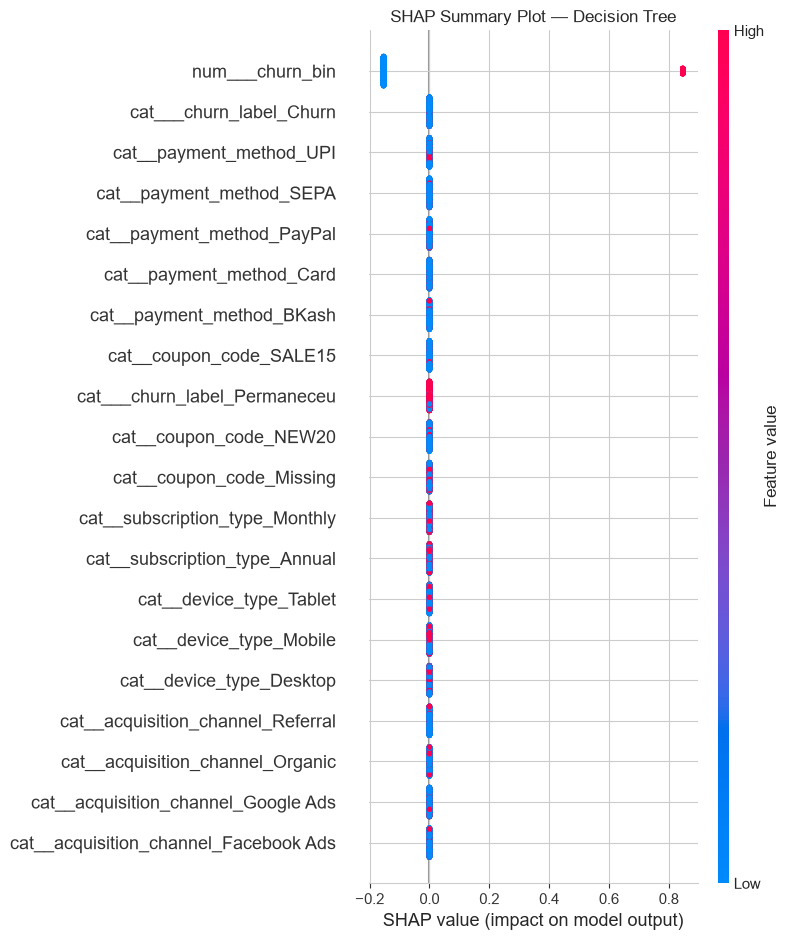

,feature,mean_abs_shap
0,num___churn_bin,0.261552
1,num__is_premium_user,0.000000
2,num__total_visits,0.000000
3,num__avg_session_time,0.000000
4,num__pages_per_session,0.000000
5,num__email_open_rate,0.000000
6,num__email_click_rate,0.000000
7,num__total_spent,0.000000
8,num__age,0.000000
9,num__avg_order_value,0.000000


C:\Users\RHADY\AppData\Local\Temp\ipykernel_25240\4240703182.py:223: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_array_for_plot, X_shap_sample, feature_names=feature_names, show=False)


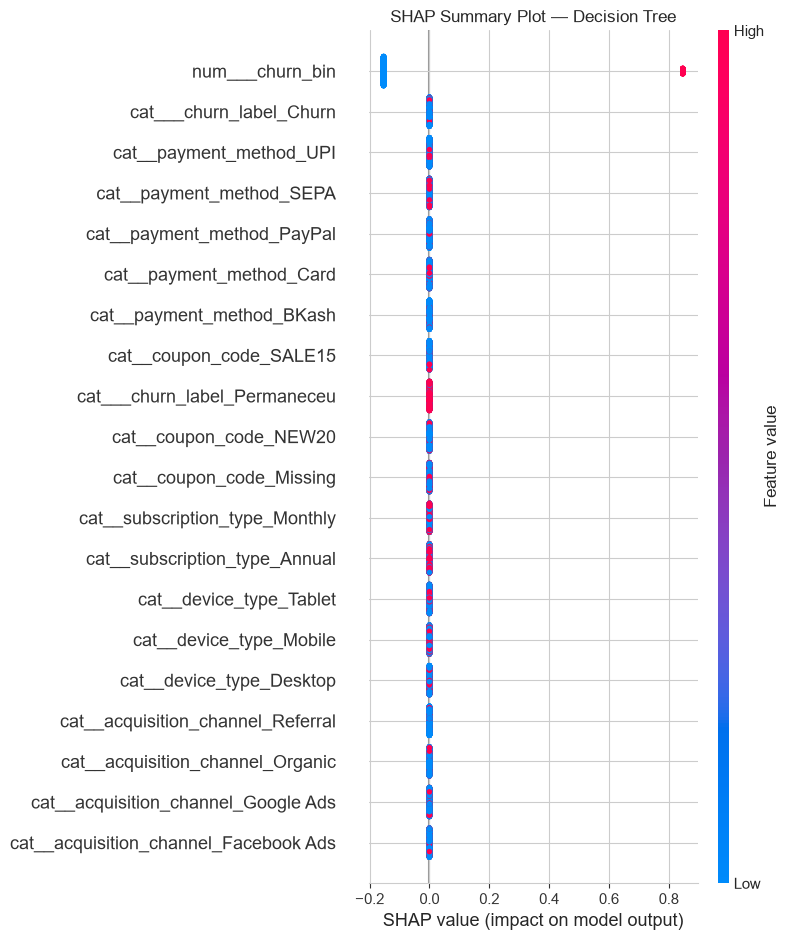

,feature,mean_abs_shap
0,num___churn_bin,0.261552
1,num__is_premium_user,0.000000
2,num__total_visits,0.000000
3,num__avg_session_time,0.000000
4,num__pages_per_session,0.000000
5,num__email_open_rate,0.000000
6,num__email_click_rate,0.000000
7,num__total_spent,0.000000
8,num__age,0.000000
9,num__avg_order_value,0.000000


In [39]:
# Ajustar uma cópia do pipeline preditivo (sem a camada de calibração) para explicabilidade.
interpretation_pipeline = clone(best_tuned_estimator)
interpretation_pipeline.fit(X_train, y_train)
classifier_for_shap = interpretation_pipeline.named_steps["classifier"]

# Transformar X_test usando o mesmo pipeline de inferência, sem aplicar resampling no teste.
if "preprocessor" in interpretation_pipeline.named_steps:
    pre = interpretation_pipeline.named_steps["preprocessor"]
    X_test_transformed = pre.transform(X_test)
    feature_names = list(pre.get_feature_names_out())
elif "pre_smotenc" in interpretation_pipeline.named_steps:
    pre = interpretation_pipeline.named_steps["pre_smotenc"]
    post = interpretation_pipeline.named_steps["post_smotenc"]
    X_pre = pre.transform(X_test)
    X_test_transformed = post.transform(X_pre)

    # Nomes legíveis: numéricas originais + categorias mapeadas de volta do ordinal.
    feature_names = list(numeric_features)
    ordinal = pre.named_transformers_["cat"].named_steps["ordinal"]
    onehot = post.named_transformers_["cat"]
    for original_name, original_categories, encoded_categories in zip(
        categorical_features, ordinal.categories_, onehot.categories_
    ):
        for encoded_value in encoded_categories:
            idx = int(round(float(encoded_value)))
            if 0 <= idx < len(original_categories):
                label = original_categories[idx]
            else:
                label = "Unknown"
            feature_names.append(f"{original_name}={label}")
else:
    raise RuntimeError("Pipeline selecionado não possui transformação reconhecida para SHAP.")

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

SHAP_SAMPLE_SIZE = min(800, X_test_transformed.shape[0])
# ============================================================
# SHAP — EXPLICABILIDADE DO MODELO FINAL
# ============================================================

# Para evitar custo computacional excessivo, usamos uma amostra
# do conjunto de teste exclusivamente para visualização SHAP.
#
# IMPORTANTE:
# O modelo continua sendo avaliado no conjunto de teste completo.
# Esta amostragem afeta apenas a etapa de explicabilidade visual.

SHAP_SAMPLE_SIZE = min(800, X_test_transformed.shape[0])

rng = np.random.RandomState(RANDOM_STATE)

sample_idx = rng.choice(
    X_test_transformed.shape[0],
    SHAP_SAMPLE_SIZE,
    replace=False
)

X_shap_sample = X_test_transformed[sample_idx]


# ============================================================
# POR QUE USAMOS TreeExplainer?
# ============================================================
#
# O modelo selecionado é baseado em árvores (XGBoost).
#
# O SHAP possui um algoritmo especializado para modelos de
# árvores chamado TreeExplainer.
#
# A configuração:
#
#     feature_perturbation="tree_path_dependent"
#
# é utilizada porque o XGBoost selecionado contém divisões
# categóricas.
#
# Nesta configuração, o SHAP utiliza a estrutura e os caminhos
# internos das árvores como referência, sem exigir um dataset
# externo de background.
#
# Isso também evita a incompatibilidade observada entre
# background interventional e categorical splits do XGBoost.

explainer = shap.TreeExplainer(
    classifier_for_shap,
    feature_perturbation="tree_path_dependent",
    feature_names=feature_names,
)


# ============================================================
# CALCULAR SHAP VALUES
# ============================================================

shap_values = explainer(X_shap_sample)


# ============================================================
# TRATAR FORMATO DA SAÍDA
# ============================================================
#
# Dependendo da versão do SHAP e do classificador, o resultado
# pode possuir:
#
# (n_amostras, n_features)
#
# ou
#
# (n_amostras, n_features, n_classes)
#
# Em classificação binária, quando existe uma dimensão para
# classes, queremos explicar a classe positiva:
#
# churn = 1.

shap_array = np.asarray(shap_values.values)

if shap_array.ndim == 3:
    positive_output = 1 if shap_array.shape[2] > 1 else 0
    shap_array_for_plot = shap_array[:, :, positive_output]
else:
    shap_array_for_plot = shap_array


# ============================================================
# VERIFICAÇÃO DE SEGURANÇA
# ============================================================

if shap_array_for_plot.shape[1] != len(feature_names):
    raise ValueError(
        "O número de valores SHAP não corresponde ao número "
        "de features transformadas."
    )

print("SHAP calculado com sucesso.")
print("Amostras explicadas:", shap_array_for_plot.shape[0])
print("Features explicadas:", shap_array_for_plot.shape[1])


# ============================================================
# SHAP SUMMARY / BEESWARM
# ============================================================
#
# Cada ponto representa um cliente da amostra.
#
# Eixo Y:
# features do modelo.
#
# Eixo X:
# contribuição SHAP daquela feature para a saída do modelo.
#
# IMPORTANTE:
# SHAP explica o comportamento do modelo.
# SHAP NÃO demonstra causalidade.

shap.summary_plot(
    shap_array_for_plot,
    X_shap_sample,
    feature_names=feature_names,
    show=False
)

plt.title(f"SHAP Summary Plot — {SELECTED_MODEL_NAME}")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "shap_summary.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# IMPORTÂNCIA GLOBAL DAS FEATURES
# ============================================================
#
# Calculamos a média do valor absoluto de SHAP.
#
# O valor absoluto é utilizado porque aqui queremos medir
# magnitude da influência, independentemente de a feature
# aumentar ou reduzir a saída do modelo.

mean_abs_shap = np.abs(shap_array_for_plot).mean(axis=0)

shap_importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap
    })
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)


# Mostrar as 20 features com maior importância média.

display(shap_importance_df.head(20))


# Salvar resultado para reutilização no dashboard,
# documentação e demais análises.

shap_importance_df.to_csv(
    RESULTS_DIR / "shap_feature_importance.csv",
    index=False
)

# Alguns classificadores retornam uma dimensão extra para as classes.
# Para classificação binária, explicar a saída da classe positiva (churn).
shap_array = np.asarray(shap_values.values)
if shap_array.ndim == 3:
    positive_output = 1 if shap_array.shape[2] > 1 else 0
    shap_array_for_plot = shap_array[:, :, positive_output]
else:
    shap_array_for_plot = shap_array

shap.summary_plot(shap_array_for_plot, X_shap_sample, feature_names=feature_names, show=False)
plt.title(f"SHAP Summary Plot — {SELECTED_MODEL_NAME}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_summary.png", dpi=160, bbox_inches="tight")
plt.show()

mean_abs_shap = np.abs(shap_array_for_plot).mean(axis=0)
shap_importance_df = (
    pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
display(shap_importance_df.head(20))
shap_importance_df.to_csv(RESULTS_DIR / "shap_feature_importance.csv", index=False) 

### 8.1 Descobertas baseadas no modelo

Depois da avaliação final, os erros do modelo e a relação risco × valor podem ser explorados. Nenhum score ou cliente é criado artificialmente.

In [40]:
scored_test = df_features.loc[X_test.index].copy()
scored_test["churn_real"] = y_test.to_numpy()
scored_test["churn_previsto"] = y_pred_final
scored_test["probabilidade_churn"] = y_proba_final

conditions = [
    (scored_test["churn_real"] == 1) & (scored_test["churn_previsto"] == 1),
    (scored_test["churn_real"] == 0) & (scored_test["churn_previsto"] == 1),
    (scored_test["churn_real"] == 1) & (scored_test["churn_previsto"] == 0),
    (scored_test["churn_real"] == 0) & (scored_test["churn_previsto"] == 0),
]
labels = ["True Positive", "False Positive", "False Negative", "True Negative"]
scored_test["tipo_resultado"] = np.select(conditions, labels, default="Indefinido")

value_candidates = [c for c in ["lifetime_value", "total_spent"] if c in scored_test.columns]
if value_candidates:
    value_col = value_candidates[0]
    fig_risk_value = plot_risk_value_scatter(
        scored_test,
        value_col=value_col,
        risk_col="probabilidade_churn",
        customer_id_col="customer_id" if "customer_id" in scored_test.columns else None,
    )
    fig_risk_value.show()
    save_fig(fig_risk_value, f"discovery_risk_vs_{value_col}.png")
else:
    print("Esta visualização não foi criada porque o dataset não possui medida válida de valor do cliente.")

error_profile_candidates = [
    c for c in numeric_discovery["variavel"].tolist()
    if c in scored_test.columns and pd.api.types.is_numeric_dtype(scored_test[c])
][:3]

for col in error_profile_candidates:
    fig_error = plot_error_profile(scored_test, col)
    fig_error.show()
    save_fig(fig_error, f"discovery_error_profile_{col}.png")

error_counts = (
    scored_test["tipo_resultado"].value_counts()
    .rename_axis("tipo_resultado")
    .reset_index(name="quantidade")
)
display(error_counts)
error_counts.to_csv(RESULTS_DIR / "validation_error_counts.csv", index=False)

,tipo_resultado,quantidade
0,True Negative,2540
1,True Positive,460


## 9. Insights de Negócio

Insights só aparecem quando há evidência calculada. Resultados descritivos, preditivos e explicações SHAP permanecem diferenciados.

In [41]:
print("=== Descobertas descritivas desta execução ===")
if discoveries_df.empty:
    print("Não foi identificado um padrão suficientemente relevante nesta análise.")
else:
    for i, row in discoveries_df.reset_index(drop=True).iterrows():
        print(f"{i + 1}. {row['resultado']}")

print("\n=== Validação preditiva desta execução ===")
for key, value in final_test_metrics.items():
    if isinstance(value, (float, np.floating)):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

print("\n=== Importância média |SHAP| ===")
display(shap_importance_df.head(15))

=== Descobertas descritivas desta execução ===
1. Valores de _churn_bin tendem a ser maior no grupo Churn nesta amostra; efeito rank-biserial=1.000.
2. Valores de total_spent tendem a ser menor no grupo Churn nesta amostra; efeito rank-biserial=-0.407.
3. Valores de satisfaction_score tendem a ser menor no grupo Churn nesta amostra; efeito rank-biserial=-0.401.
4. Valores de support_tickets tendem a ser maior no grupo Churn nesta amostra; efeito rank-biserial=0.135.
5. _churn_label apresenta associação com churn nesta amostra; Cramér's V=1.000.
6. O segmento _churn_bin=1 possui taxa de churn 100.00% vs. 15.32% na base (diferença de +84.68 p.p.).
7. O segmento support_tickets=6 possui taxa de churn 50.61% vs. 15.32% na base (diferença de +35.29 p.p.).
8. O segmento support_tickets=5 possui taxa de churn 50.18% vs. 15.32% na base (diferença de +34.86 p.p.).
9. O segmento satisfaction_score=2.0 possui taxa de churn 50.17% vs. 15.32% na base (diferença de +34.85 p.p.).
10. O segmento satis

,feature,mean_abs_shap
0,num___churn_bin,0.261552
1,num__is_premium_user,0.000000
2,num__total_visits,0.000000
3,num__avg_session_time,0.000000
4,num__pages_per_session,0.000000
5,num__email_open_rate,0.000000
6,num__email_click_rate,0.000000
7,num__total_spent,0.000000
8,num__age,0.000000
9,num__avg_order_value,0.000000


## 10. Recomendações

Recomendações seguem **evidência → interpretação → recomendação**. Sem evidência suficiente, o notebook não gera ação específica.

In [42]:
if discoveries_df.empty:
    print(
        "Não há evidência descritiva suficiente nesta execução para gerar recomendações específicas. "
        "Resultado pendente de evidência adicional."
    )
else:
    print("Pontos de investigação baseados nas evidências calculadas:")
    for i, row in discoveries_df.reset_index(drop=True).iterrows():
        if row["tipo"] == "Segmento":
            print(
                f"{i + 1}. Investigar o segmento {row['variavel']}={row['categoria']} em testes/controlados "
                "antes de qualquer ação em escala; a diferença observada não prova causalidade."
            )
        else:
            print(
                f"{i + 1}. Investigar {row['variavel']} como sinal potencial de segmentação/priorização, "
                f"pois apresentou evidência do tipo {row['metrica']}; validar impacto causal separadamente."
            )

Pontos de investigação baseados nas evidências calculadas:
1. Investigar _churn_bin como sinal potencial de segmentação/priorização, pois apresentou evidência do tipo rank-biserial; validar impacto causal separadamente.
2. Investigar total_spent como sinal potencial de segmentação/priorização, pois apresentou evidência do tipo rank-biserial; validar impacto causal separadamente.
3. Investigar satisfaction_score como sinal potencial de segmentação/priorização, pois apresentou evidência do tipo rank-biserial; validar impacto causal separadamente.
4. Investigar support_tickets como sinal potencial de segmentação/priorização, pois apresentou evidência do tipo rank-biserial; validar impacto causal separadamente.
5. Investigar _churn_label como sinal potencial de segmentação/priorização, pois apresentou evidência do tipo Cramér's V; validar impacto causal separadamente.
6. Investigar o segmento _churn_bin=1 em testes/controlados antes de qualquer ação em escala; a diferença observada não pro

## 11. Auditoria Final da Metodologia

A auditoria abaixo não é preenchida manualmente como “tudo certo”. Cada status é derivado das etapas efetivamente executadas nesta sessão.

In [43]:
validation_audit = build_validation_audit(
    split_checks,
    cross_validation_completed=CROSS_VALIDATION_COMPLETED,
    imbalance_strategies_compared=IMBALANCE_STRATEGIES_COMPARED,
    hyperparameter_tuning_completed=HYPERPARAMETER_TUNING_COMPLETED,
    leakage_audit_completed=LEAKAGE_AUDIT_COMPLETED,
    calibration_evaluated=CALIBRATION_EVALUATED,
    threshold_selected_without_test=THRESHOLD_SELECTED_WITHOUT_TEST,
    overfitting_checked=OVERFITTING_CHECKED,
    final_test_evaluated=FINAL_TEST_EVALUATED,
)

audit_df = pd.DataFrame(
    [{"verificacao": key, "status": bool(value)} for key, value in validation_audit.items()]
)
display(audit_df)

with open(RESULTS_DIR / "validation_audit.json", "w", encoding="utf-8") as f:
    json.dump(validation_audit, f, ensure_ascii=False, indent=2)

failed = [key for key, ok in validation_audit.items() if not ok]
if failed:
    print("Validações pendentes ou não atendidas:", failed)
else:
    print("Todas as validações instrumentadas nesta execução foram concluídas.")

,verificacao,status
0,test_set_isolated,True
1,stratified_split,True
2,cross_validation_completed,True
3,imbalance_strategies_compared,True
4,hyperparameter_tuning_completed,True
5,leakage_audit_completed,True
6,calibration_evaluated,True
7,threshold_selected_without_test,True
8,overfitting_checked,True
9,final_test_evaluated,True


Todas as validações instrumentadas nesta execução foram concluídas.


---

## Encerramento

Checklist antes do commit final:

- [ ] Reiniciar o kernel e executar todas as células em ordem (*Restart & Run All*)
- [ ] Confirmar ausência de erros
- [ ] Confirmar que `reports/results/validation_audit.json` reflete a execução atual
- [ ] Confirmar que o test set só foi acessado na seção de avaliação final
- [ ] Confirmar que o README não contém métricas de uma execução antiga apresentadas como resultado atual
- [ ] Confirmar que nenhum dado sintético de teste aparece nas conclusões
- [ ] Confirmar que gráficos interativos usam apenas resultados calculados
- [ ] Versionar o pipeline final somente após a execução completa